# M1 Implementation

In [1]:
!pip -q install neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 20.1 MB/s eta 0:00:00


In [2]:
import os
from neo4j import GraphDatabase

NEO4J_URI = "neo4j+s://18806529.databases.neo4j.io"
NEO4J_USER = "18806529"
NEO4J_PASSWORD = "rwx6BIN-eh1E4PdFy2Wc-JWLZnvrwT13AEsiZX7i-Bs"
NEO4J_DB = "18806529"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

with driver.session(database=NEO4J_DB) as session:
    row = session.run("RETURN 1 AS ok").single()
    print("Connected! ok =", row["ok"])

driver.close()

Connected! ok = 1


In [3]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
with driver.session(database=NEO4J_DB) as session:
    session.run("RETURN 'hello' AS msg").single()
    print("Database reachable:", NEO4J_DB)
driver.close()

Database reachable: 18806529


In [4]:
!pip -q install requests beautifulsoup4 lxml spacy
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 104.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
import os
os.environ["SEC_USER_AGENT"] = "nkommi@asu.edu"

In [6]:
%%writefile module1_sec_ner_to_neo4j.py
import os, re, time, random, argparse
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple, Optional

import requests
from bs4 import BeautifulSoup
import spacy
from neo4j import GraphDatabase


# ---------- SEC helpers ----------
def cik10(cik: str) -> str:
    return re.sub(r"\D", "", cik).zfill(10)

def sec_get(url: str, user_agent: str, max_retries: int = 6) -> requests.Response:
    headers = {"User-Agent": user_agent, "Accept-Encoding": "gzip, deflate"}
    last_exc = None
    for attempt in range(max_retries):
        try:
            r = requests.get(url, headers=headers, timeout=60)
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep((2 ** attempt) + random.random())
                continue
            r.raise_for_status()
            time.sleep(0.2)  # be polite to SEC
            return r
        except Exception as e:
            last_exc = e
            time.sleep((2 ** attempt) + random.random())
    raise RuntimeError(f"SEC request failed: {url}") from last_exc

def ticker_to_cik(ticker: str, user_agent: str) -> str:
    data = sec_get("https://www.sec.gov/files/company_tickers.json", user_agent).json()
    t = ticker.upper().strip()
    for _, row in data.items():
        if str(row.get("ticker", "")).upper() == t:
            return cik10(str(row["cik_str"]))
    raise ValueError(f"Ticker not found: {ticker}")

def fetch_submissions(cik: str, user_agent: str) -> Dict[str, Any]:
    return sec_get(f"https://data.sec.gov/submissions/CIK{cik10(cik)}.json", user_agent).json()

@dataclass(frozen=True)
class FilingRef:
    cik: str
    accession_no: str
    primary_doc: str
    filing_date: str
    report_date: str
    form: str

def pick_latest_form(submissions: Dict[str, Any], form: str = "10-K") -> FilingRef:
    recent = submissions.get("filings", {}).get("recent", {})
    forms = recent.get("form", [])
    accs = recent.get("accessionNumber", [])
    docs = recent.get("primaryDocument", [])
    filing_dates = recent.get("filingDate", [])
    report_dates = recent.get("reportDate", [])
    for i, f in enumerate(forms):
        if f == form:
            return FilingRef(
                cik=str(submissions.get("cik", "")),
                accession_no=accs[i],
                primary_doc=docs[i],
                filing_date=filing_dates[i],
                report_date=report_dates[i],
                form=f,
            )
    raise ValueError(f"No {form} found in recent filings.")

def archive_url(cik: str, accession_no: str, primary_doc: str) -> str:
    acc_nodash = accession_no.replace("-", "")
    cik_int = str(int(cik))
    return f"https://www.sec.gov/Archives/edgar/data/{cik_int}/{acc_nodash}/{primary_doc}"

def download_filing(filing: FilingRef, user_agent: str, out_dir: str) -> str:
    os.makedirs(out_dir, exist_ok=True)
    url = archive_url(filing.cik, filing.accession_no, filing.primary_doc)
    r = sec_get(url, user_agent)
    out_path = os.path.join(out_dir, f"{filing.accession_no}_{filing.primary_doc}")
    with open(out_path, "wb") as f:
        f.write(r.content)
    return out_path


# ---------- Parse + NER ----------
def html_to_text(path: str) -> str:
    with open(path, "rb") as f:
        raw = f.read()
    soup = BeautifulSoup(raw, "lxml")
    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()
    text = soup.get_text(separator="\n")
    lines = [ln.strip() for ln in text.splitlines()]
    lines = [ln for ln in lines if ln]
    return "\n".join(lines)

def extract_entities(text: str, max_chars: int = 250_000) -> List[Tuple[str, str]]:
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text[:max_chars])
    rows = []
    for ent in doc.ents:
        name = ent.text.strip()
        if len(name) < 2:
            continue
        rows.append((name, ent.label_))
    # de-dup
    return list({(n, t) for n, t in rows})


# ---------- Neo4j ----------
class Neo4jStore:
    def __init__(self, uri: str, user: str, password: str, database: str) -> None:
        self.database = database
        self.driver = GraphDatabase.driver(uri, auth=(user, password))

    def close(self) -> None:
        self.driver.close()

    def init_schema(self) -> None:
        stmts = [
            "CREATE CONSTRAINT filing_accession IF NOT EXISTS FOR (f:Filing) REQUIRE f.accession_no IS UNIQUE",
            "CREATE CONSTRAINT entity_name IF NOT EXISTS FOR (e:Entity) REQUIRE e.name IS UNIQUE",
        ]
        with self.driver.session(database=self.database) as s:
            for st in stmts:
                s.run(st)

    def upsert_filing(self, filing: FilingRef) -> None:
        q = """
        MERGE (f:Filing {accession_no: $acc})
        SET f.cik=$cik, f.form=$form, f.filing_date=$fd, f.report_date=$rd, f.primary_doc=$doc
        """
        with self.driver.session(database=self.database) as s:
            s.run(q, acc=filing.accession_no, cik=cik10(filing.cik), form=filing.form,
                  fd=filing.filing_date, rd=filing.report_date, doc=filing.primary_doc)

    def upsert_entities_and_mentions(self, accession_no: str, entities: List[Tuple[str, str]]) -> None:
        q = """
        MATCH (f:Filing {accession_no: $acc})
        UNWIND $rows AS row
        MERGE (e:Entity {name: row.name})
        SET e.type = row.type
        MERGE (f)-[:MENTIONS]->(e)
        """
        rows = [{"name": n, "type": t} for n, t in entities]
        with self.driver.session(database=self.database) as s:
            s.run(q, acc=accession_no, rows=rows)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--ticker", default=None)
    ap.add_argument("--cik", default=None)
    ap.add_argument("--form", default="10-K")
    ap.add_argument("--out_dir", default="/content/sec_data")
    ap.add_argument("--max_chars", type=int, default=250000)
    args = ap.parse_args()

    ua = os.environ.get("SEC_USER_AGENT", "").strip()
    if not ua:
        raise ValueError("SEC_USER_AGENT must be set (Name email@domain.com).")

    cik = args.cik
    if not cik and args.ticker:
        cik = ticker_to_cik(args.ticker, ua)
    if not cik:
        raise ValueError("Provide --ticker or --cik")

    subs = fetch_submissions(cik, ua)
    filing = pick_latest_form(subs, form=args.form)

    path = download_filing(filing, ua, args.out_dir)
    text = html_to_text(path)
    entities = extract_entities(text, max_chars=args.max_chars)

    uri = os.environ["NEO4J_URI"]
    user = os.environ["NEO4J_USERNAME"]
    pwd = os.environ["NEO4J_PASSWORD"]
    db = os.environ["NEO4J_DATABASE"]

    store = Neo4jStore(uri, user, pwd, db)
    try:
        store.init_schema()
        store.upsert_filing(filing)
        store.upsert_entities_and_mentions(filing.accession_no, entities)
    finally:
        store.close()

    print(f"Loaded {filing.form} accession={filing.accession_no} cik={cik10(filing.cik)}")
    print(f"Entities added: {len(entities)}")


if __name__ == "__main__":
    main()

Writing module1_sec_ner_to_neo4j.py


In [7]:
import os
os.environ["NEO4J_URI"] = "neo4j+s://18806529.databases.neo4j.io"
os.environ["NEO4J_USERNAME"] = "18806529"
os.environ["NEO4J_PASSWORD"] = "rwx6BIN-eh1E4PdFy2Wc-JWLZnvrwT13AEsiZX7i-Bs"
os.environ["NEO4J_DATABASE"] = "18806529"

In [8]:
!python module1_sec_ner_to_neo4j.py --ticker AAPL --form 10-K --out_dir /content/sec_data --max_chars 250000

/content/module1_sec_ner_to_neo4j.py:90: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(raw, "lxml")
Loaded 10-K accession=0000320193-25-000079 cik=0000320193
Entities added: 1628


In [9]:
from neo4j import GraphDatabase
import os

driver = GraphDatabase.driver(os.environ["NEO4J_URI"], auth=(os.environ["NEO4J_USERNAME"], os.environ["NEO4J_PASSWORD"]))

with driver.session(database=os.environ["NEO4J_DATABASE"]) as session:
    print("Filings:", session.run("MATCH (f:Filing) RETURN count(f) AS c").single()["c"])
    print("Entities:", session.run("MATCH (e:Entity) RETURN count(e) AS c").single()["c"])
    print("Mentions:", session.run("MATCH (:Filing)-[r:MENTIONS]->(:Entity) RETURN count(r) AS c").single()["c"])

driver.close()


Filings: 4
Entities: 4291
Mentions: 4932


In [10]:
import re, pathlib

p = pathlib.Path("module1_sec_ner_to_neo4j.py")
txt = p.read_text()

# Replace extract_entities() to return dict counts instead of de-duped list
txt = re.sub(
    r"def extract_entities\(text: str, max_chars: int = 250_000\) -> List\[Tuple\[str, str\]\]:.*?return list\(\{\(n, t\) for n, t in rows\}\)\n",
    """def extract_entities(text: str, max_chars: int = 250_000):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text[:max_chars])

    counts = {}  # (name,type) -> count
    for ent in doc.ents:
        name = ent.text.strip()
        if len(name) < 2:
            continue
        key = (name, ent.label_)
        counts[key] = counts.get(key, 0) + 1
    return counts
""",
    txt,
    flags=re.DOTALL
)

# Replace upsert_entities_and_mentions() to use count on relationship
txt = re.sub(
    r"def upsert_entities_and_mentions\(self, accession_no: str, entities: List\[Tuple\[str, str\]\]\) -> None:.*?s\.run\(q, acc=accession_no, rows=rows\)\n",
    """def upsert_entities_and_mentions(self, accession_no: str, entities) -> None:
        q = '''
        MATCH (f:Filing {accession_no: $acc})
        UNWIND $rows AS row
        MERGE (e:Entity {name: row.name})
        SET e.type = row.type
        MERGE (f)-[m:MENTIONS]->(e)
        SET m.count = row.count
        '''
        rows = [{"name": n, "type": t, "count": c} for (n, t), c in entities.items()]
        with self.driver.session(database=self.database) as s:
            s.run(q, acc=accession_no, rows=rows)
""",
    txt,
    flags=re.DOTALL
)

# Fix the printed entity count
txt = txt.replace('print(f"Entities added: {len(entities)}")', 'print(f"Entities added (unique): {len(entities)}")')

p.write_text(txt)
print("Patched script to store mention counts.")

Patched script to store mention counts.


In [11]:
!python module1_sec_ner_to_neo4j.py --ticker AAPL --form 10-K --out_dir /content/sec_data --max_chars 250000

/content/module1_sec_ner_to_neo4j.py:90: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(raw, "lxml")
Loaded 10-K accession=0000320193-25-000079 cik=0000320193
Entities added (unique): 1628


In [12]:
from neo4j import GraphDatabase
import os

driver = GraphDatabase.driver(os.environ["NEO4J_URI"], auth=(os.environ["NEO4J_USERNAME"], os.environ["NEO4J_PASSWORD"]))
with driver.session(database=os.environ["NEO4J_DATABASE"]) as session:
    res = session.run("""
    MATCH (f:Filing)-[m:MENTIONS]->(e:Entity)
    RETURN e.name AS name, e.type AS type, m.count AS c
    ORDER BY c DESC
    LIMIT 20
    """)
    for r in res:
        print(r["c"], r["type"], r["name"])
driver.close()

367 DATE 0001018724
346 ORG Company
183 DATE 2025-06-30
0000789019
135 DATE 2026-01-25
125 DATE 2024-06-30
0000789019
107 CARDINAL 2025
98 DATE 2024-12-31
86 DATE 2025-12-31
86 DATE 2024-07-01
80 DATE 2025-09-27
75 ORG Apple Inc.
73 DATE 2025-01
71 GPE China
62 GPE U.S.
62 ORG Microsoft
59 DATE 2025-01-01
59 ORDINAL third
58 DATE 2024-09-28
58 DATE 2023-12-31
58 PRODUCT Form 10-K


In [13]:
!python module1_sec_ner_to_neo4j.py --ticker MSFT --form 10-K --out_dir /content/sec_data --max_chars 250000

/content/module1_sec_ner_to_neo4j.py:90: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(raw, "lxml")
Loaded 10-K accession=0000950170-25-100235 cik=0000789019
Entities added (unique): 1124


In [55]:
from neo4j import GraphDatabase
import os

driver = GraphDatabase.driver(
    os.environ["NEO4J_URI"],
    auth=(os.environ["NEO4J_USERNAME"], os.environ["NEO4J_PASSWORD"])
)
with driver.session(database=os.environ["NEO4J_DATABASE"]) as session:
    session.run("MATCH (n) DETACH DELETE n")
driver.close()

print("Cleared graph.")

Cleared graph.


In [15]:
import pathlib, re

p = pathlib.Path("module1_sec_ner_to_neo4j.py")
txt = p.read_text()

# 1) Add company constraint
txt = txt.replace(
    '"CREATE CONSTRAINT entity_name IF NOT EXISTS FOR (e:Entity) REQUIRE e.name IS UNIQUE",',
    '"CREATE CONSTRAINT entity_name IF NOT EXISTS FOR (e:Entity) REQUIRE e.name IS UNIQUE",\n'
    '            "CREATE CONSTRAINT company_cik IF NOT EXISTS FOR (c:Company) REQUIRE c.cik IS UNIQUE",'
)

# 2) Add upsert_company method
if "def upsert_company" not in txt:
    txt = txt.replace(
        "def upsert_filing(self, filing: FilingRef) -> None:",
        """def upsert_company(self, cik: str, ticker: str) -> None:
        q = \"\"\"
        MERGE (c:Company {cik: $cik})
        SET c.ticker = $ticker
        \"\"\"
        with self.driver.session(database=self.database) as s:
            s.run(q, cik=cik, ticker=ticker)

    def upsert_filing(self, filing: FilingRef) -> None:"""
    )

# 3) Link Company -> Filing
txt = txt.replace(
    "MERGE (f:Filing {accession_no: $acc})",
    "MERGE (f:Filing {accession_no: $acc})\n        WITH f\n        MERGE (c:Company {cik: $cik})\n        MERGE (c)-[:FILED]->(f)"
)

# 4) Ensure cik param still exists in run call (it does), so no further changes needed.

# 5) In main(), call upsert_company before upsert_filing
txt = txt.replace(
    "store.init_schema()\n        store.upsert_filing(filing)",
    "store.init_schema()\n        store.upsert_company(cik10(filing.cik), args.ticker or '')\n        store.upsert_filing(filing)"
)

p.write_text(txt)
print("Patched: added Company nodes + (Company)-[:FILED]->(Filing).")

Patched: added Company nodes + (Company)-[:FILED]->(Filing).


In [56]:
import os, re, time, random, requests, pathlib
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple, Optional
from bs4 import BeautifulSoup
import spacy
from neo4j import GraphDatabase

# ── helpers (same as module1 script) ─────────────────────────────────────────
def cik10(cik): return re.sub(r"\D", "", cik).zfill(10)

def sec_get(url, user_agent, max_retries=6):
    headers = {"User-Agent": user_agent, "Accept-Encoding": "gzip, deflate"}
    for attempt in range(max_retries):
        try:
            r = requests.get(url, headers=headers, timeout=60)
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep((2**attempt) + random.random())
                continue
            r.raise_for_status()
            time.sleep(0.2)
            return r
        except Exception as e:
            time.sleep((2**attempt) + random.random())
    raise RuntimeError(f"SEC request failed: {url}")

def ticker_to_cik(ticker, user_agent):
    data = sec_get("https://www.sec.gov/files/company_tickers.json", user_agent).json()
    for _, row in data.items():
        if str(row.get("ticker","")).upper() == ticker.upper():
            return cik10(str(row["cik_str"]))
    raise ValueError(f"Ticker not found: {ticker}")

def fetch_submissions(cik, user_agent):
    return sec_get(f"https://data.sec.gov/submissions/CIK{cik10(cik)}.json", user_agent).json()

@dataclass(frozen=True)
class FilingRef:
    cik: str
    accession_no: str
    primary_doc: str
    filing_date: str
    report_date: str
    form: str

def pick_filings_by_years(submissions, form="10-K", year_start=2017, year_end=2024):
    """Return all filings of given form within year range."""
    recent       = submissions.get("filings", {}).get("recent", {})
    forms        = recent.get("form", [])
    accs         = recent.get("accessionNumber", [])
    docs         = recent.get("primaryDocument", [])
    filing_dates = recent.get("filingDate", [])
    report_dates = recent.get("reportDate", [])
    results = []
    for i, f in enumerate(forms):
        if f != form:
            continue
        rd = report_dates[i] or filing_dates[i]
        if not rd:
            continue
        year = int(rd[:4])
        if year_start <= year <= year_end:
            results.append(FilingRef(
                cik=str(submissions.get("cik", "")),
                accession_no=accs[i],
                primary_doc=docs[i],
                filing_date=filing_dates[i],
                report_date=rd,
                form=f,
            ))
    return results

def archive_url(cik, accession_no, primary_doc):
    acc_nodash = accession_no.replace("-", "")
    return f"https://www.sec.gov/Archives/edgar/data/{int(cik)}/{acc_nodash}/{primary_doc}"

def download_filing(filing, user_agent, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    url      = archive_url(filing.cik, filing.accession_no, filing.primary_doc)
    r        = sec_get(url, user_agent)
    out_path = os.path.join(out_dir, f"{filing.accession_no}_{filing.primary_doc}")
    with open(out_path, "wb") as f:
        f.write(r.content)
    return out_path

def html_to_text(path):
    with open(path, "rb") as f:
        raw = f.read()
    soup = BeautifulSoup(raw, "lxml")
    for tag in soup(["script","style","noscript"]):
        tag.decompose()
    text  = soup.get_text(separator="\n")
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    return "\n".join(lines)

def extract_entities(text, max_chars=250_000):
    nlp    = spacy.load("en_core_web_sm")
    doc    = nlp(text[:max_chars])
    counts = {}
    for ent in doc.ents:
        name = ent.text.strip()
        if len(name) < 2:
            continue
        key          = (name, ent.label_)
        counts[key]  = counts.get(key, 0) + 1
    return counts

# ── Neo4j store ───────────────────────────────────────────────────────────────
class Neo4jStore:
    def __init__(self, uri, user, password, database):
        self.database = database
        self.driver   = GraphDatabase.driver(uri, auth=(user, password))

    def close(self):
        self.driver.close()

    def init_schema(self):
        stmts = [
            "CREATE CONSTRAINT filing_accession IF NOT EXISTS FOR (f:Filing) REQUIRE f.accession_no IS UNIQUE",
            "CREATE CONSTRAINT entity_name IF NOT EXISTS FOR (e:Entity) REQUIRE e.name IS UNIQUE",
            "CREATE CONSTRAINT company_cik IF NOT EXISTS FOR (c:Company) REQUIRE c.cik IS UNIQUE",
        ]
        with self.driver.session(database=self.database) as s:
            for st in stmts:
                s.run(st)

    def upsert_company(self, cik, ticker):
        with self.driver.session(database=self.database) as s:
            s.run("MERGE (c:Company {cik:$cik}) SET c.ticker=$ticker",
                  cik=cik, ticker=ticker)

    def upsert_filing(self, filing):
        q = """
        MERGE (f:Filing {accession_no: $acc})
        SET f.cik=$cik, f.form=$form, f.filing_date=$fd,
            f.report_date=$rd, f.primary_doc=$doc
        WITH f
        MERGE (c:Company {cik: $cik})
        MERGE (c)-[:FILED]->(f)
        """
        with self.driver.session(database=self.database) as s:
            s.run(q, acc=filing.accession_no, cik=cik10(filing.cik),
                  form=filing.form, fd=filing.filing_date,
                  rd=filing.report_date, doc=filing.primary_doc)

    def upsert_entities(self, accession_no, entities):
        q = """
        MATCH (f:Filing {accession_no: $acc})
        UNWIND $rows AS row
        MERGE (e:Entity {name: row.name})
        SET e.type = row.type
        MERGE (f)-[m:MENTIONS]->(e)
        SET m.count = row.count
        """
        rows = [{"name":n,"type":t,"count":c} for (n,t),c in entities.items()]
        with self.driver.session(database=self.database) as s:
            s.run(q, acc=accession_no, rows=rows)


# ── Main ingestion loop ───────────────────────────────────────────────────────
UA       = os.environ.get("SEC_USER_AGENT", "nkommi@asu.edu")
OUT_DIR  = "/content/sec_data"
TICKERS  = ["AAPL", "MSFT", "AMZN", "NVDA"]

# Year ranges per ticker to maximise FinanceBench + EVAL_QUERIES coverage
YEAR_RANGES = {
    "AAPL": (2022, 2024),   # covers EVAL_QUERIES FY2023
    "MSFT": (2022, 2024),   # covers EVAL_QUERIES FY2023 + FinanceBench FY2023
    "AMZN": (2017, 2024),   # covers FinanceBench FY2017 + EVAL_QUERIES FY2023
    "NVDA": (2022, 2024),   # covers EVAL_QUERIES FY2023
}

store = Neo4jStore(
    uri=os.environ["NEO4J_URI"],
    user=os.environ["NEO4J_USERNAME"],
    password=os.environ["NEO4J_PASSWORD"],
    database=os.environ["NEO4J_DATABASE"]
)
store.init_schema()

total_filings = 0

for ticker in TICKERS:
    print(f"\n{'='*50}")
    print(f"Ticker: {ticker}")
    year_start, year_end = YEAR_RANGES[ticker]

    cik      = ticker_to_cik(ticker, UA)
    subs     = fetch_submissions(cik, UA)
    filings  = pick_filings_by_years(subs, year_start=year_start,
                                     year_end=year_end)

    if not filings:
        print(f"  WARNING: No filings found for {ticker} "
              f"between {year_start}-{year_end}")
        continue

    print(f"  Found {len(filings)} filing(s):")
    for fl in filings:
        print(f"    {fl.report_date}  {fl.accession_no}")

    store.upsert_company(cik10(cik), ticker)

    for filing in filings:
        print(f"\n  Ingesting {filing.report_date}...")
        path     = download_filing(filing, UA, OUT_DIR)
        text     = html_to_text(path)
        entities = extract_entities(text, max_chars=250_000)
        store.upsert_filing(filing)
        store.upsert_entities(filing.accession_no, entities)
        print(f"    Entities: {len(entities)}")
        total_filings += 1

store.close()
print(f"\nDone. Total filings ingested: {total_filings}")


Ticker: AAPL
  Found 3 filing(s):
    2024-09-28  0000320193-24-000123
    2023-09-30  0000320193-23-000106
    2022-09-24  0000320193-22-000108

  Ingesting 2024-09-28...


/tmp/ipykernel_1604/882753242.py:88: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(raw, "lxml")


    Entities: 1588

  Ingesting 2023-09-30...
    Entities: 1633

  Ingesting 2022-09-24...
    Entities: 1620

Ticker: MSFT
  Found 3 filing(s):
    2024-06-30  0000950170-24-087843
    2023-06-30  0000950170-23-035122
    2022-06-30  0001564590-22-026876

  Ingesting 2024-06-30...
    Entities: 959

  Ingesting 2023-06-30...
    Entities: 1169

  Ingesting 2022-06-30...
    Entities: 1026

Ticker: AMZN
  Found 6 filing(s):
    2024-12-31  0001018724-25-000004
    2023-12-31  0001018724-24-000008
    2022-12-31  0001018724-23-000004
    2021-12-31  0001018724-22-000005
    2020-12-31  0001018724-21-000004
    2019-12-31  0001018724-20-000004

  Ingesting 2024-12-31...
    Entities: 1447

  Ingesting 2023-12-31...
    Entities: 1459

  Ingesting 2022-12-31...
    Entities: 1556

  Ingesting 2021-12-31...
    Entities: 1646

  Ingesting 2020-12-31...
    Entities: 1579

  Ingesting 2019-12-31...
    Entities: 1561

Ticker: NVDA
  Found 3 filing(s):
    2024-01-28  0001045810-24-000029
 

In [17]:
from neo4j import GraphDatabase
import os

driver = GraphDatabase.driver(
    os.environ["NEO4J_URI"],
    auth=(os.environ["NEO4J_USERNAME"], os.environ["NEO4J_PASSWORD"])
)

with driver.session(database=os.environ["NEO4J_DATABASE"]) as session:
    print("Companies:", session.run("MATCH (c:Company) RETURN count(c) AS c").single()["c"])
    print("Filings:", session.run("MATCH (f:Filing) RETURN count(f) AS c").single()["c"])
    print("Entities:", session.run("MATCH (e:Entity) RETURN count(e) AS c").single()["c"])
    print("Mentions:", session.run("MATCH ()-[r:MENTIONS]->() RETURN count(r) AS c").single()["c"])
    print("FILED edges:", session.run("MATCH (:Company)-[r:FILED]->(:Filing) RETURN count(r) AS c").single()["c"])

    print("\nFilings per company:")
    res = session.run("""
        MATCH (c:Company)-[:FILED]->(f:Filing)
        RETURN c.ticker AS ticker, c.cik AS cik, count(f) AS filings
        ORDER BY ticker
    """)
    for r in res:
        print(r["ticker"], r["cik"], "->", r["filings"])

driver.close()

Companies: 4
Filings: 4
Entities: 4291
Mentions: 4932
FILED edges: 4

Filings per company:
AAPL 0000320193 -> 1
AMZN 0001018724 -> 1
MSFT 0000789019 -> 1
NVDA 0001045810 -> 1


In [18]:
from neo4j import GraphDatabase
import os

driver = GraphDatabase.driver(
    os.environ["NEO4J_URI"],
    auth=(os.environ["NEO4J_USERNAME"], os.environ["NEO4J_PASSWORD"])
)

with driver.session(database=os.environ["NEO4J_DATABASE"]) as session:
    companies = session.run("MATCH (c:Company) RETURN count(c) AS c").single()["c"]
    filings = session.run("MATCH (f:Filing) RETURN count(f) AS c").single()["c"]
    entities = session.run("MATCH (e:Entity) RETURN count(e) AS c").single()["c"]
    mentions = session.run("MATCH ()-[r:MENTIONS]->() RETURN count(r) AS c").single()["c"]
    filed = session.run("MATCH ()-[r:FILED]->() RETURN count(r) AS c").single()["c"]

driver.close()

total_nodes = companies + filings + entities
total_rels = mentions + filed
total_elements = total_nodes + total_rels

print("Core dataset (documents):", filings, "10-K filings across", companies, "companies")
print("Graph nodes:", total_nodes, f"(Company={companies}, Filing={filings}, Entity={entities})")
print("Graph relationships:", total_rels, f"(MENTIONS={mentions}, FILED={filed})")
print("Total graph elements (nodes+rels):", total_elements)

Core dataset (documents): 4 10-K filings across 4 companies
Graph nodes: 4299 (Company=4, Filing=4, Entity=4291)
Graph relationships: 4936 (MENTIONS=4932, FILED=4)
Total graph elements (nodes+rels): 9235


In [19]:
!pip -q install requests beautifulsoup4 lxml

In [20]:
%%writefile download_10k_last20y.py
import os, re, csv, time, random, argparse
from datetime import datetime, timedelta
from typing import Dict, Any, List, Tuple
import requests

def cik10(cik: str) -> str:
    return re.sub(r"\D", "", cik).zfill(10)

def sec_get(url: str, user_agent: str, max_retries: int = 8) -> requests.Response:
    headers = {"User-Agent": user_agent, "Accept-Encoding": "gzip, deflate"}
    last_exc = None
    for attempt in range(max_retries):
        try:
            r = requests.get(url, headers=headers, timeout=60)
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep((2 ** attempt) + random.random())
                continue
            r.raise_for_status()
            time.sleep(0.2)
            return r
        except Exception as e:
            last_exc = e
            time.sleep((2 ** attempt) + random.random())
    raise RuntimeError(f"SEC request failed: {url}") from last_exc

def ticker_to_cik(ticker: str, user_agent: str) -> str:
    data = sec_get("https://www.sec.gov/files/company_tickers.json", user_agent).json()
    t = ticker.upper().strip()
    for _, row in data.items():
        if str(row.get("ticker", "")).upper() == t:
            return cik10(str(row["cik_str"]))
    raise ValueError(f"Ticker not found: {ticker}")

def fetch_submissions(cik: str, user_agent: str) -> Dict[str, Any]:
    return sec_get(f"https://data.sec.gov/submissions/CIK{cik10(cik)}.json", user_agent).json()

def archive_url(cik: str, accession_no: str, primary_doc: str) -> str:
    acc_nodash = accession_no.replace("-", "")
    cik_int = str(int(cik))
    return f"https://www.sec.gov/Archives/edgar/data/{cik_int}/{acc_nodash}/{primary_doc}"

def parse_date(d: str) -> datetime:
    return datetime.strptime(d, "%Y-%m-%d")

def collect_10ks(submissions: Dict[str, Any], cutoff: datetime, include_amendments: bool) -> List[Dict[str, str]]:
    recent = submissions.get("filings", {}).get("recent", {})
    forms = recent.get("form", [])
    accs = recent.get("accessionNumber", [])
    docs = recent.get("primaryDocument", [])
    filing_dates = recent.get("filingDate", [])
    report_dates = recent.get("reportDate", [])

    out = []
    for f, acc, doc, fd, rd in zip(forms, accs, docs, filing_dates, report_dates):
        if f == "10-K" or (include_amendments and f == "10-K/A"):
            if fd and parse_date(fd) >= cutoff:
                out.append({
                    "form": f,
                    "accession_no": acc,
                    "primary_doc": doc,
                    "filing_date": fd,
                    "report_date": rd or "",
                })
    return out

def download_one(url: str, user_agent: str, out_path: str) -> None:
    headers = {"User-Agent": user_agent, "Accept-Encoding": "gzip, deflate"}
    r = requests.get(url, headers=headers, timeout=60)
    r.raise_for_status()
    with open(out_path, "wb") as f:
        f.write(r.content)
    time.sleep(0.2)

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--tickers", nargs="+", required=True)
    ap.add_argument("--years", type=int, default=20)
    ap.add_argument("--out_dir", default="/content/sec_10k_last20y")
    ap.add_argument("--include_amendments", action="store_true")
    args = ap.parse_args()

    ua = os.environ.get("SEC_USER_AGENT", "").strip()
    if not ua:
        raise ValueError("SEC_USER_AGENT must be set (Name email@domain.com).")

    cutoff = datetime.utcnow() - timedelta(days=365 * args.years)

    os.makedirs(args.out_dir, exist_ok=True)
    manifest_path = os.path.join(args.out_dir, "manifest.csv")

    rows = []
    for ticker in args.tickers:
        cik = ticker_to_cik(ticker, ua)
        subs = fetch_submissions(cik, ua)
        filings = collect_10ks(subs, cutoff=cutoff, include_amendments=args.include_amendments)

        company_dir = os.path.join(args.out_dir, ticker.upper())
        os.makedirs(company_dir, exist_ok=True)

        for f in filings:
            url = archive_url(cik, f["accession_no"], f["primary_doc"])
            fname = f'{f["accession_no"]}_{f["primary_doc"]}'
            out_path = os.path.join(company_dir, fname)

            if not os.path.exists(out_path):
                download_one(url, ua, out_path)

            rows.append({
                "ticker": ticker.upper(),
                "cik": cik10(cik),
                "form": f["form"],
                "accession_no": f["accession_no"],
                "filing_date": f["filing_date"],
                "report_date": f["report_date"],
                "primary_doc": f["primary_doc"],
                "url": url,
                "local_path": out_path,
            })

        print(f"{ticker.upper()}: downloaded/recorded {len(filings)} filings since {cutoff.date()}")

    # write manifest
    with open(manifest_path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()) if rows else [])
        if rows:
            w.writeheader()
            w.writerows(rows)

    print("Manifest:", manifest_path)
    print("Total filings recorded:", len(rows))

if __name__ == "__main__":
    main()

Writing download_10k_last20y.py


In [21]:
import os
os.environ["SEC_USER_AGENT"] = "Hari your_email@asu.edu"  # required

!python download_10k_last20y.py --tickers AAPL MSFT AMZN NVDA --years 20 --out_dir /content/sec_10k_last20y

/content/download_10k_last20y.py:86: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  cutoff = datetime.utcnow() - timedelta(days=365 * args.years)
AAPL: downloaded/recorded 11 filings since 2006-03-22
MSFT: downloaded/recorded 6 filings since 2006-03-22
AMZN: downloaded/recorded 7 filings since 2006-03-22
NVDA: downloaded/recorded 7 filings since 2006-03-22
Manifest: /content/sec_10k_last20y/manifest.csv
Total filings recorded: 31


In [22]:
!python download_10k_last20y.py --tickers AAPL MSFT AMZN NVDA --years 20 --out_dir /content/sec_10k_last20y --include_amendments

/content/download_10k_last20y.py:86: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  cutoff = datetime.utcnow() - timedelta(days=365 * args.years)
AAPL: downloaded/recorded 11 filings since 2006-03-22
MSFT: downloaded/recorded 6 filings since 2006-03-22
AMZN: downloaded/recorded 7 filings since 2006-03-22
NVDA: downloaded/recorded 7 filings since 2006-03-22
Manifest: /content/sec_10k_last20y/manifest.csv
Total filings recorded: 31


# M2 - KG-Grounded Hybrid Retrieval
Builds on M1's Neo4j KG + downloaded 10-K filings:
1. Ollama (llama3.2 + nomic-embed-text) running inside Colab
2. FAISS vector index from chunked 10-K text
3. KG traversal: query -> entity match -> Neo4j subgraph
4. Hybrid retrieval: FAISS + KG with entity-guided re-ranking
5. Comparison: Hybrid vs Vector-Only baseline


In [23]:
!pip -q install faiss-cpu langchain langchain-community \
               beautifulsoup4 lxml tqdm matplotlib requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [24]:
import subprocess, time, requests as req

# Step 1: Install zstd (required by Ollama installer)
print("Installing zstd...")
subprocess.run("apt-get install -y zstd", shell=True, check=True,
               capture_output=True)
print("zstd installed.")

# Step 2: Install Ollama
print("Installing Ollama...")
r = subprocess.run(
    "curl -fsSL https://ollama.com/install.sh | sh",
    shell=True, capture_output=True, text=True
)
print(r.stdout[-300:] if r.stdout else "")
if r.returncode != 0:
    print("STDERR:", r.stderr[-300:])
    raise RuntimeError("Ollama install failed")
print("Ollama installed.")

# Step 3: Start Ollama server in background
subprocess.Popen(["ollama", "serve"],
                 stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(6)

# Step 4: Verify server is up
for attempt in range(4):
    try:
        resp = req.get("http://localhost:11434", timeout=10)
        print("Ollama server ready:", resp.text.strip())
        break
    except Exception:
        print(f"  Waiting... attempt {attempt+1}")
        time.sleep(8)
else:
    raise RuntimeError("Ollama server did not start. Check runtime logs.")

Installing zstd...
zstd installed.
Installing Ollama...

Ollama installed.
Ollama server ready: Ollama is running


In [25]:
import subprocess

for model in ['llama3.2', 'nomic-embed-text']:
    print(f'Pulling {model}...')
    subprocess.run(['ollama', 'pull', model], check=True)
    print(f'  {model} ready.')

result = subprocess.run(['ollama', 'list'], capture_output=True, text=True)
print('Available models:\n', result.stdout)


Pulling llama3.2...
  llama3.2 ready.
Pulling nomic-embed-text...
  nomic-embed-text ready.
Available models:
 NAME                       ID              SIZE      MODIFIED               
nomic-embed-text:latest    0a109f422b47    274 MB    Less than a second ago    
llama3.2:latest            a80c4f17acd5    2.0 GB    9 seconds ago             



In [57]:
import os
from neo4j import GraphDatabase

NEO4J_URI      = os.environ.get('NEO4J_URI',      'neo4j+s://18806529.databases.neo4j.io')
NEO4J_USERNAME = os.environ.get('NEO4J_USERNAME',  '18806529')
NEO4J_PASSWORD = os.environ.get('NEO4J_PASSWORD',  'rwx6BIN-eh1E4PdFy2Wc-JWLZnvrwT13AEsiZX7i-Bs')
NEO4J_DATABASE = os.environ.get('NEO4J_DATABASE',  '18806529')

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
with driver.session(database=NEO4J_DATABASE) as session:
    companies = session.run('MATCH (c:Company) RETURN count(c) AS c').single()['c']
    entities  = session.run('MATCH (e:Entity)  RETURN count(e) AS c').single()['c']
    print(f'Neo4j connected - Companies: {companies}, Entities: {entities}')
driver.close()


Neo4j connected - Companies: 4, Entities: 9645


In [59]:
import os, shutil
from pathlib import Path

# Copy newly ingested filings into the directory M2 expects
SRC = "/content/sec_data"
DST = "/content/sec_10k_last20y"

for fname in Path(SRC).glob("*"):
    if fname.is_file():
        # figure out ticker from accession number is hard,
        # so just put everything in a general folder
        dest_dir = os.path.join(DST, "ALL")
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy2(str(fname), os.path.join(dest_dir, fname.name))

print("Files copied:")
for f in Path(DST).rglob("*"):
    if f.is_file():
        print(f"  {f}")

Files copied:
  /content/sec_10k_last20y/manifest.csv
  /content/sec_10k_last20y/MSFT/0001564590-22-026876_msft-10k_20220630.htm
  /content/sec_10k_last20y/MSFT/0000950170-25-100235_msft-20250630.htm
  /content/sec_10k_last20y/MSFT/0001564590-20-034944_msft-10k_20200630.htm
  /content/sec_10k_last20y/MSFT/0000950170-24-087843_msft-20240630.htm
  /content/sec_10k_last20y/MSFT/0001564590-21-039151_msft-10k_20210630.htm
  /content/sec_10k_last20y/MSFT/0000950170-23-035122_msft-20230630.htm
  /content/sec_10k_last20y/AAPL/0000320193-17-000070_a10-k20179302017.htm
  /content/sec_10k_last20y/AAPL/0001628280-16-020309_a201610-k9242016.htm
  /content/sec_10k_last20y/AAPL/0001193125-15-356351_d17062d10k.htm
  /content/sec_10k_last20y/AAPL/0000320193-21-000105_aapl-20210925.htm
  /content/sec_10k_last20y/AAPL/0000320193-25-000079_aapl-20250927.htm
  /content/sec_10k_last20y/AAPL/0000320193-19-000119_a10-k20199282019.htm
  /content/sec_10k_last20y/AAPL/0000320193-23-000106_aapl-20230930.htm
  /co

In [60]:
import os, re
from pathlib import Path
from bs4 import BeautifulSoup
from tqdm import tqdm
from collections import Counter

FILING_DIR    = '/content/sec_10k_last20y'
CHUNK_SIZE    = 512
CHUNK_OVERLAP = 64

# Suppress XML warning
import warnings
from bs4 import XMLParsedAsHTMLWarning
warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

def html_to_text(path):
    with open(path, 'rb') as f:
        raw = f.read()
    soup = BeautifulSoup(raw, 'lxml')
    for tag in soup(['script', 'style', 'noscript']):
        tag.decompose()
    text = soup.get_text(separator=' ')
    return re.sub(r'\s+', ' ', text).strip()

def chunk_text(text, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    words = text.split()
    chunks, start = [], 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append(' '.join(words[start:end]))
        if end == len(words):
            break
        start += chunk_size - overlap
    return chunks

def get_year_from_filename(fname):
    """Extract year from filename like aapl-20230930.htm -> 2023"""
    m = re.search(r'(\d{4})\d{4}\.htm', fname)
    if m:
        return m.group(1)
    m = re.search(r'(\d{4})', fname)
    return m.group(1) if m else 'unknown'

# Ticker mapping — skip ALL folder (duplicates)
TICKER_DIRS = {
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'AMZN': 'Amazon',
    'NVDA': 'NVIDIA',
}

all_chunks = []

for ticker in TICKER_DIRS:
    ticker_dir = Path(FILING_DIR) / ticker
    if not ticker_dir.exists():
        print(f"WARNING: {ticker_dir} not found, skipping.")
        continue

    # Get all htm files, sorted by filename (which encodes date)
    files = sorted(
        [f for f in ticker_dir.iterdir()
         if f.suffix in ('.htm', '.html') and f.stat().st_size > 10000],
        key=lambda f: f.name
    )

    print(f"\n{ticker}: {len(files)} filing(s) found")

    for fpath in tqdm(files, desc=f"  Chunking {ticker}"):
        year = get_year_from_filename(fpath.name)
        text = html_to_text(str(fpath))
        chunks = chunk_text(text)
        for i, chunk in enumerate(chunks):
            all_chunks.append({
                'text':         chunk,
                'ticker':       ticker,
                'accession_no': fpath.stem,
                'filing_date':  year,
                'chunk_id':     f"{ticker}_{fpath.stem}_chunk{i}",
            })

        print(f"    {fpath.name} ({year}): {len(chunks)} chunks")

print(f"\nTotal chunks: {len(all_chunks)}")
for t, cnt in Counter(c['ticker'] for c in all_chunks).items():
    print(f"  {t}: {cnt} chunks")


AAPL: 11 filing(s) found


  Chunking AAPL:   9%|▉         | 1/11 [00:02<00:21,  2.19s/it]

    0000320193-17-000070_a10-k20179302017.htm (7930): 103 chunks


  Chunking AAPL:  18%|█▊        | 2/11 [00:03<00:15,  1.72s/it]

    0000320193-18-000145_a10-k20189292018.htm (8929): 97 chunks


...

    0001045810-24-000029_nvda-20240128.htm (2024): 119 chunks


  Chunking NVDA:  86%|████████▌ | 6/7 [00:06<00:00,  1.02it/s]

    0001045810-25-000023_nvda-20250126.htm (2025): 122 chunks


  Chunking NVDA: 100%|██████████| 7/7 [00:07<00:00,  1.04s/it]

    0001045810-26-000021_nvda-20260125.htm (2026): 119 chunks

Total chunks: 3106
  AAPL: 944 chunks
  MSFT: 715 chunks
  AMZN: 666 chunks
  NVDA: 781 chunks


In [61]:
import requests, numpy as np, faiss, pickle
from tqdm import tqdm

OLLAMA_EMBED_URL = 'http://localhost:11434/api/embeddings'
EMBED_MODEL      = 'nomic-embed-text'
FAISS_INDEX_PATH = '/content/faiss_index.bin'
CHUNKS_PATH      = '/content/chunks_metadata.pkl'

def get_embedding(text):
    r = requests.post(OLLAMA_EMBED_URL,
                      json={'model': EMBED_MODEL, 'prompt': text},
                      timeout=60)
    r.raise_for_status()
    return np.array(r.json()['embedding'], dtype=np.float32)

print(f'Embedding {len(all_chunks)} chunks with {EMBED_MODEL}...')
print('(Slow step - several minutes expected on Colab GPU)')

embeddings, failed = [], []
for i, chunk in enumerate(tqdm(all_chunks, desc='Embedding')):
    try:
        embeddings.append(get_embedding(chunk['text']))
    except Exception as e:
        print(f'  Chunk {i} failed: {e}')
        failed.append(i)
        embeddings.append(np.zeros(768, dtype=np.float32))

mat = np.vstack(embeddings)
print(f'Embedding matrix shape: {mat.shape}')

# Normalize for cosine similarity, build flat inner-product FAISS index
faiss.normalize_L2(mat)
dim   = mat.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(mat)
print(f'FAISS index: {index.ntotal} vectors, dim={dim}')

faiss.write_index(index, FAISS_INDEX_PATH)
with open(CHUNKS_PATH, 'wb') as f:
    pickle.dump(all_chunks, f)

print(f'Saved FAISS index    -> {FAISS_INDEX_PATH}')
print(f'Saved chunk metadata -> {CHUNKS_PATH}')
if failed:
    print(f'WARNING: {len(failed)} chunks failed embedding (zero vector used).')

Embedding 3106 chunks with nomic-embed-text...
(Slow step - several minutes expected on Colab GPU)


Embedding:   7%|▋         | 204/3106 [00:12<02:06, 23.01it/s]

  Chunk 200 failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings
  Chunk 201 failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings
  Chunk 202 failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings


Embedding:   9%|▉         | 289/3106 [00:16<01:59, 23.58it/s]

  Chunk 285 failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings
  Chunk 286 failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings
  Chunk 287 failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings


...

  Chunk 2865 failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings
  Chunk 2866 failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings


Embedding:  96%|█████████▋| 2991/3106 [02:49<00:06, 18.12it/s]

  Chunk 2987 failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings
  Chunk 2988 failed: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings


Embedding: 100%|██████████| 3106/3106 [02:55<00:00, 17.68it/s]


Embedding matrix shape: (3106, 768)
FAISS index: 3106 vectors, dim=768
Saved FAISS index    -> /content/faiss_index.bin
Saved chunk metadata -> /content/chunks_metadata.pkl


In [62]:
import re
from neo4j import GraphDatabase

class KGRetriever:
    def __init__(self, uri, user, password, database):
        self.driver        = GraphDatabase.driver(uri, auth=(user, password))
        self.database      = database
        self._entity_cache = None  # lazy-loaded

    def close(self):
        self.driver.close()

    def _load_entity_cache(self):
        with self.driver.session(database=self.database) as s:
            rows = s.run('MATCH (e:Entity) RETURN e.name AS name, e.type AS type')
            self._entity_cache = [(r['name'], r['type']) for r in rows]
        print(f'KG entity cache loaded: {len(self._entity_cache)} entities')

    def match_entities(self, query, top_k=10):
        if self._entity_cache is None:
            self._load_entity_cache()
        q_lower  = query.lower()
        q_tokens = set(re.findall(r'\b\w+\b', q_lower))
        scored = []
        for name, etype in self._entity_cache:
            n_lower = name.lower()
            if n_lower in q_lower:
                scored.append((3, name, etype))
            else:
                overlap = len(q_tokens & set(re.findall(r'\b\w+\b', n_lower)))
                if overlap > 0:
                    scored.append((overlap, name, etype))
        scored.sort(key=lambda x: -x[0])
        return [(name, etype) for _, name, etype in scored[:top_k]]

    def get_entity_subgraph(self, entity_name):
        q = '''
        MATCH (e:Entity {name: $name})<-[m:MENTIONS]-(f:Filing)<-[:FILED]-(c:Company)
        OPTIONAL MATCH (f)-[m2:MENTIONS]->(e2:Entity) WHERE e2.name <> $name
        RETURN
            e.name         AS entity,
            e.type         AS entity_type,
            c.ticker       AS ticker,
            f.accession_no AS accession,
            f.filing_date  AS filing_date,
            m.count        AS mention_count,
            collect(DISTINCT {name: e2.name, type: e2.type, count: m2.count})[..10]
                           AS co_entities
        ORDER BY m.count DESC
        LIMIT 5
        '''
        with self.driver.session(database=self.database) as s:
            rows = list(s.run(q, name=entity_name))
        return [
            {
                'entity':        r['entity'],
                'entity_type':   r['entity_type'],
                'ticker':        r['ticker'],
                'accession':     r['accession'],
                'filing_date':   r['filing_date'],
                'mention_count': r['mention_count'],
                'co_entities':   [e for e in (r['co_entities'] or []) if e.get('name')],
            }
            for r in rows
        ]

    def retrieve(self, query, top_k_entities=5):
        matched    = self.match_entities(query, top_k=top_k_entities)
        kg_context = []
        for name, etype in matched:
            subgraph = self.get_entity_subgraph(name)
            if subgraph:
                kg_context.append({'entity': name, 'type': etype, 'subgraph': subgraph})
        return {'query': query, 'matched_entities': matched, 'kg_context': kg_context}

    def format_context(self, kg_result):
        lines = ['=== Knowledge Graph Context ===']
        if not kg_result['kg_context']:
            lines.append('(No KG entities matched for this query)')
            return '\n'.join(lines)
        for item in kg_result['kg_context']:
            lines.append(f"\nEntity: {item['entity']} (Type: {item['type']})")
            for row in item['subgraph']:
                lines.append(
                    f"  * {row['ticker']} 10-K ({row['filing_date']}) "
                    f"- mentioned {row['mention_count']} times"
                )
                if row['co_entities']:
                    co = ', '.join(e['name'] for e in row['co_entities'][:5] if e.get('name'))
                    lines.append(f'    Co-entities: {co}')
        lines.append('==============================')
        return '\n'.join(lines)


# Instantiate KG Retriever
kg_retriever = KGRetriever(
    uri=NEO4J_URI, user=NEO4J_USERNAME,
    password=NEO4J_PASSWORD, database=NEO4J_DATABASE
)

# Sanity check
test = kg_retriever.retrieve('What is Apple revenue from iPhone?', top_k_entities=3)
print('Matched entities:', test['matched_entities'])
print()
print(kg_retriever.format_context(test))


KG entity cache loaded: 9645 entities
Matched entities: [('One', 'CARDINAL'), ('Apple', 'ORG'), ('iPhone', 'ORG')]

=== Knowledge Graph Context ===

Entity: One (Type: CARDINAL)
  * MSFT 10-K (2022-07-28) - mentioned 2 times
    Co-entities: EUR, ProductMember, 2021-09, CashMember, ForeignGovernmentDebtSecuritiesMember
  * AMZN 10-K (2025-02-07) - mentioned 2 times
    Co-entities: 2024, EUR, ProductMember, 2023-09-30, ForeignGovernmentDebtSecuritiesMember
  * AMZN 10-K (2024-02-02) - mentioned 2 times
    Co-entities: 2024, EUR, 2023-10-01, ProductMember, 2023-09-30
  * AMZN 10-K (2023-02-03) - mentioned 2 times
    Co-entities: 2024, EUR, ProductMember, 2022-09, ForeignGovernmentDebtSecuritiesMember
  * NVDA 10-K (2024-02-21) - mentioned 2 times
    Co-entities: 2024, ForeignGovernmentDebtSecuritiesMember, FairValueInputsLevel2Member, OperatingSegmentsMember, US

Entity: Apple (Type: ORG)
  * AAPL 10-K (2023-11-03) - mentioned 13 times
    Co-entities: 2024, 0000320193, EUR, 2023-10-

In [63]:
import faiss, pickle, numpy as np, requests

class FAISSRetriever:
    def __init__(self, index_path, chunks_path,
                 embed_model='nomic-embed-text',
                 ollama_url='http://localhost:11434/api/embeddings'):
        self.index       = faiss.read_index(index_path)
        with open(chunks_path, 'rb') as f:
            self.chunks  = pickle.load(f)
        self.embed_model = embed_model
        self.ollama_url  = ollama_url
        print(f'FAISS index loaded: {self.index.ntotal} vectors')
        print(f'Chunks loaded     : {len(self.chunks)}')

    def embed(self, text):
        r = requests.post(self.ollama_url,
                          json={'model': self.embed_model, 'prompt': text},
                          timeout=60)
        r.raise_for_status()
        vec = np.array(r.json()['embedding'], dtype=np.float32).reshape(1, -1)
        faiss.normalize_L2(vec)
        return vec

    def retrieve(self, query, top_k=5):
        scores, indices = self.index.search(self.embed(query), top_k)
        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx == -1:
                continue
            chunk = self.chunks[idx].copy()
            chunk['score'] = float(score)
            results.append(chunk)
        return results

    def format_context(self, results):
        lines = ['=== Vector Retrieval Context ===']
        for i, r in enumerate(results, 1):
            lines.append(
                f"\n[Chunk {i} | {r['ticker']} | {r['filing_date']} | score={r['score']:.4f}]"
            )
            lines.append(r['text'][:600])
        lines.append('================================')
        return '\n'.join(lines)


# Instantiate
faiss_retriever = FAISSRetriever(
    index_path=FAISS_INDEX_PATH,
    chunks_path=CHUNKS_PATH,
)

# Sanity check
test_chunks = faiss_retriever.retrieve('Apple iPhone revenue 2023', top_k=3)
for c in test_chunks:
    print(f"[{c['ticker']} | score={c['score']:.4f}] {c['text'][:120]}...")


FAISS index loaded: 3106 vectors
Chunks loaded     : 3106
[NVDA | score=0.7253] year 2023, we had $7.23 billion remaining under our share repurchase authorization through December 2023. Market Platfor...
[AMZN | score=0.7225] 2023 As Reported Exchange Rate Effect (1) At Prior Year Rates (2) As Reported Exchange Rate Effect (1) At Prior Year Rat...
[AAPL | score=0.7220] $ 29,375 $ 26,356 Operating income $ 12,066 $ 11,569 $ 9,817 A reconciliation of the Company’s segment operating income ...


In [64]:
class HybridRetriever:
    KG_BOOST = 0.15  # score bonus for chunks from KG-matched tickers

    def __init__(self, faiss_retriever, kg_retriever):
        self.faiss = faiss_retriever
        self.kg    = kg_retriever

    def retrieve(self, query, top_k=5, kg_top_k=5):
        faiss_results = self.faiss.retrieve(query, top_k=top_k)
        kg_result     = self.kg.retrieve(query, top_k_entities=kg_top_k)

        # Tickers confirmed relevant by the KG
        kg_tickers = {
            row['ticker']
            for item in kg_result['kg_context']
            for row in item['subgraph']
            if row.get('ticker')
        }

        # Apply KG relevance boost and re-rank
        for chunk in faiss_results:
            if chunk.get('ticker') in kg_tickers:
                chunk['hybrid_score'] = chunk['score'] + self.KG_BOOST
                chunk['kg_boosted']   = True
            else:
                chunk['hybrid_score'] = chunk['score']
                chunk['kg_boosted']   = False

        faiss_results.sort(key=lambda x: -x['hybrid_score'])

        return {
            'query':         query,
            'faiss_results': faiss_results,
            'kg_result':     kg_result,
            'kg_tickers':    list(kg_tickers),
        }

    def format_combined_context(self, retrieval, max_chunks=5):
        parts = [self.kg.format_context(retrieval['kg_result'])]
        parts.append('\n=== Relevant Document Passages ===')
        for i, chunk in enumerate(retrieval['faiss_results'][:max_chunks], 1):
            tag = ' [KG-boosted]' if chunk.get('kg_boosted') else ''
            parts.append(
                f"\n[Passage {i} | {chunk['ticker']} | {chunk['filing_date']}"
                f" | score={chunk['hybrid_score']:.4f}{tag}]"
            )
            parts.append(chunk['text'][:600])
        parts.append('==================================')
        return '\n'.join(parts)


# Instantiate
hybrid_retriever = HybridRetriever(faiss_retriever, kg_retriever)

# Sanity check
q   = "What is Apple's total revenue for fiscal year 2023?"
res = hybrid_retriever.retrieve(q, top_k=5, kg_top_k=5)
print(f'Query      : {q}')
print(f'KG tickers : {res["kg_tickers"]}')
print(f'KG entities: {[e[0] for e in res["kg_result"]["matched_entities"]]}')
print()
print(hybrid_retriever.format_combined_context(res))


Query      : What is Apple's total revenue for fiscal year 2023?
KG tickers : ['MSFT', 'NVDA', 'AAPL', 'AMZN']
KG entities: ['20', 'Apple', 'fiscal year', '2023', 'the fiscal year ended September\xa030, 2023']

=== Knowledge Graph Context ===

Entity: 20 (Type: CARDINAL)
  * NVDA 10-K (2022-03-18) - mentioned 3 times
    Co-entities: 2024, ForeignGovernmentDebtSecuritiesMember, FairValueInputsLevel2Member, US, Washington
  * MSFT 10-K (2023-07-27) - mentioned 3 times
    Co-entities: 2024, EUR, ProductMember, 2021-09, CashMember
  * AMZN 10-K (2025-02-07) - mentioned 3 times
    Co-entities: 2024, EUR, ProductMember, 2023-09-30, ForeignGovernmentDebtSecuritiesMember
  * AMZN 10-K (2024-02-02) - mentioned 3 times
    Co-entities: 2024, EUR, 2023-10-01, ProductMember, 2023-09-30
  * AMZN 10-K (2022-02-04) - mentioned 3 times
    Co-entities: 2024, EUR, ProductMember, OperatingSegmentsMember, US

Entity: Apple (Type: ORG)
  * AAPL 10-K (2023-11-03) - mentioned 13 times
    Co-entities: 20

In [65]:
import requests

OLLAMA_GEN_URL = 'http://localhost:11434/api/generate'
LLM_MODEL      = 'llama3.2'

def generate_answer(query, context, model=LLM_MODEL):
    prompt = (
        'You are a financial analyst assistant. '
        'Use ONLY the context below to answer the question. '
        'If the context lacks sufficient information, say so clearly.\n\n'
        f'{context}\n\n'
        f'Question: {query}\n\nAnswer:'
    )
    payload = {
        'model':   model,
        'prompt':  prompt,
        'stream':  False,
        'options': {'temperature': 0.1, 'num_predict': 300},
    }
    r = requests.post(OLLAMA_GEN_URL, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()['response'].strip()


def run_pipeline(query, mode='hybrid'):
    # mode: 'hybrid' | 'vector_only' | 'kg_only'
    if mode == 'hybrid':
        retrieval = hybrid_retriever.retrieve(query)
        context   = hybrid_retriever.format_combined_context(retrieval)
    elif mode == 'vector_only':
        results   = faiss_retriever.retrieve(query, top_k=5)
        context   = faiss_retriever.format_context(results)
        retrieval = {'faiss_results': results, 'kg_result': None}
    elif mode == 'kg_only':
        kg_result = kg_retriever.retrieve(query)
        context   = kg_retriever.format_context(kg_result)
        retrieval = {'faiss_results': [], 'kg_result': kg_result}
    else:
        raise ValueError(f'Unknown mode: {mode}')

    answer = generate_answer(query, context)
    return {'query': query, 'mode': mode, 'context': context,
            'answer': answer, 'retrieval': retrieval}


# Demo: compare all three modes
demo_query = "What is Apple's total revenue for fiscal year 2023?"
print(f'Query: {demo_query}\n')

for mode in ['vector_only', 'kg_only', 'hybrid']:
    print('=' * 60)
    print(f'MODE: {mode.upper()}')
    print('=' * 60)
    out = run_pipeline(demo_query, mode=mode)
    print(f'Answer:\n{out["answer"]}\n')


Query: What is Apple's total revenue for fiscal year 2023?

MODE: VECTOR_ONLY
Answer:
According to Chunk 5 | AAPL | 2023 | score=0.7197, the table "Other Income/(Expense), Net" does not provide Apple's total revenue for fiscal year 2023. However, in Chunk 1 | NVDA | 2024 | score=0.7394, there is a similar table that shows revenue for different years, but it doesn't match AAPL's fiscal year.

However, in Chunk 2 | AAPL | 2023 | score=0.7365, the "Reconciliation of the Company’s segment operating income to the Consolidated Statements of Operations" table provides Apple's total operating income for 2023 as $114,301 million.

MODE: KG_ONLY
Answer:
Unfortunately, the provided context does not contain sufficient information to determine Apple's (AAPL) total revenue for fiscal year 2023. The context only mentions that AAPL's 10-K report for 2024 contains references to 2023, but it does not provide any financial data or revenue figures for that year.

The context also mentions that AAPL's 10-K

In [66]:
import time, json
from collections import Counter

EVAL_QUERIES = [
    {'query':    "What is Apple's total net revenue for fiscal year 2023?",
     'ticker':   'AAPL',
     'reference': 'Apple total net revenue fiscal 2023 was approximately 383 billion dollars'},
    {'query':    "What were Microsoft's cloud revenue figures in 2023?",
     'ticker':   'MSFT',
     'reference': 'Microsoft cloud revenue including Azure grew significantly in fiscal 2023'},
    {'query':    "What is Amazon's operating income for 2023?",
     'ticker':   'AMZN',
     'reference': 'Amazon operating income for 2023 was approximately 36 billion dollars'},
    {'query':    "What is NVIDIA's data center revenue growth in fiscal 2023?",
     'ticker':   'NVDA',
     'reference': 'NVIDIA data center revenue grew substantially driven by AI demand in fiscal 2023'},
    {'query':    'What are the main risk factors disclosed by Apple?',
     'ticker':   'AAPL',
     'reference': 'Apple risk factors include competition supply chain macroeconomic conditions regulation'},
    {'query':    'How many employees does Microsoft have?',
     'ticker':   'MSFT',
     'reference': 'Microsoft has approximately 220000 full time employees worldwide'},
]

def token_f1(prediction, reference):
    """Token-level F1 score — same metric used in SQuAD evaluation."""
    pred_tokens = Counter(prediction.lower().split())
    ref_tokens  = Counter(reference.lower().split())
    common      = sum((pred_tokens & ref_tokens).values())
    if common == 0:
        return 0.0
    precision = common / sum(pred_tokens.values())
    recall    = common / sum(ref_tokens.values())
    f1        = 2 * precision * recall / (precision + recall)
    return round(f1, 3)

def answer_length_score(answer):
    """Reward more informative answers (normalized, capped at 1.0)."""
    words = len(answer.split())
    return round(min(words / 80, 1.0), 3)

results_table = []

for item in EVAL_QUERIES:
    query     = item['query']
    reference = item['reference']
    print(f'\nEval: {query[:65]}...')
    row = {'query': query, 'ticker': item['ticker'], 'reference': reference}

    for mode in ['vector_only', 'hybrid']:
        t0      = time.time()
        out     = run_pipeline(query, mode=mode)
        elapsed = round(time.time() - t0, 2)

        f1    = token_f1(out['answer'], reference)
        alen  = answer_length_score(out['answer'])
        words = len(out['answer'].split())

        row[f'{mode}_f1']      = f1
        row[f'{mode}_alen']    = alen
        row[f'{mode}_latency'] = elapsed
        row[f'{mode}_words']   = words
        row[f'{mode}_answer']  = out['answer']

        if mode == 'hybrid':
            ret = hybrid_retriever.retrieve(query)
            row['kg_entities_matched'] = len(ret['kg_result']['matched_entities'])
            row['kg_boosted_chunks']   = sum(
                1 for c in ret['faiss_results'] if c.get('kg_boosted')
            )
            row['kg_tickers'] = ret['kg_tickers']

        print(f'  [{mode:12s}] F1={f1:.3f} | len_score={alen:.3f} | {elapsed}s | {words} words')

    results_table.append(row)

# Summary
vec_avg_f1 = round(sum(r['vector_only_f1'] for r in results_table) / len(results_table), 3)
hyb_avg_f1 = round(sum(r['hybrid_f1']      for r in results_table) / len(results_table), 3)

print('\n' + '=' * 76)
print('EVALUATION SUMMARY — Token F1')
print('=' * 76)
print(f'{"Query":<46} {"Vec F1":>7} {"Hyb F1":>7} {"Delta":>7} {"KG Boost":>9}')
print('-' * 76)
for r in results_table:
    d = round(r['hybrid_f1'] - r['vector_only_f1'], 3)
    print(f"{r['query'][:45]:<46} {r['vector_only_f1']:>7.3f} "
          f"{r['hybrid_f1']:>7.3f} {d:>+7.3f} "
          f"{r.get('kg_boosted_chunks', 0):>9}")
print('-' * 76)
print(f'{"AVERAGE":<46} {vec_avg_f1:>7.3f} {hyb_avg_f1:>7.3f} '
      f'{hyb_avg_f1 - vec_avg_f1:>+7.3f}')
print('=' * 76)

with open('/content/m2_eval_results.json', 'w') as f:
    json.dump(results_table, f, indent=2)
print('\nSaved: /content/m2_eval_results.json')


Eval: What is Apple's total net revenue for fiscal year 2023?...
  [vector_only ] F1=0.055 | len_score=1.000 | 6.87s | 208 words
  [hybrid      ] F1=0.154 | len_score=0.675 | 4.83s | 54 words

Eval: What were Microsoft's cloud revenue figures in 2023?...
  [vector_only ] F1=0.106 | len_score=1.000 | 2.6s | 84 words
  [hybrid      ] F1=0.047 | len_score=1.000 | 8.28s | 159 words

Eval: What is Amazon's operating income for 2023?...
  [vector_only ] F1=0.370 | len_score=0.212 | 1.37s | 17 words
  [hybrid      ] F1=0.400 | len_score=0.188 | 3.91s | 15 words

Eval: What is NVIDIA's data center revenue growth in fiscal 2023?...
  [vector_only ] F1=0.250 | len_score=0.338 | 1.53s | 27 words
  [hybrid      ] F1=0.137 | len_score=1.000 | 5.12s | 89 words

Eval: What are the main risk factors disclosed by Apple?...
  [vector_only ] F1=0.079 | len_score=0.825 | 2.22s | 66 words
  [hybrid      ] F1=0.060 | len_score=1.000 | 20.13s | 123 words

Eval: How many employees does Microsoft have?...
  [

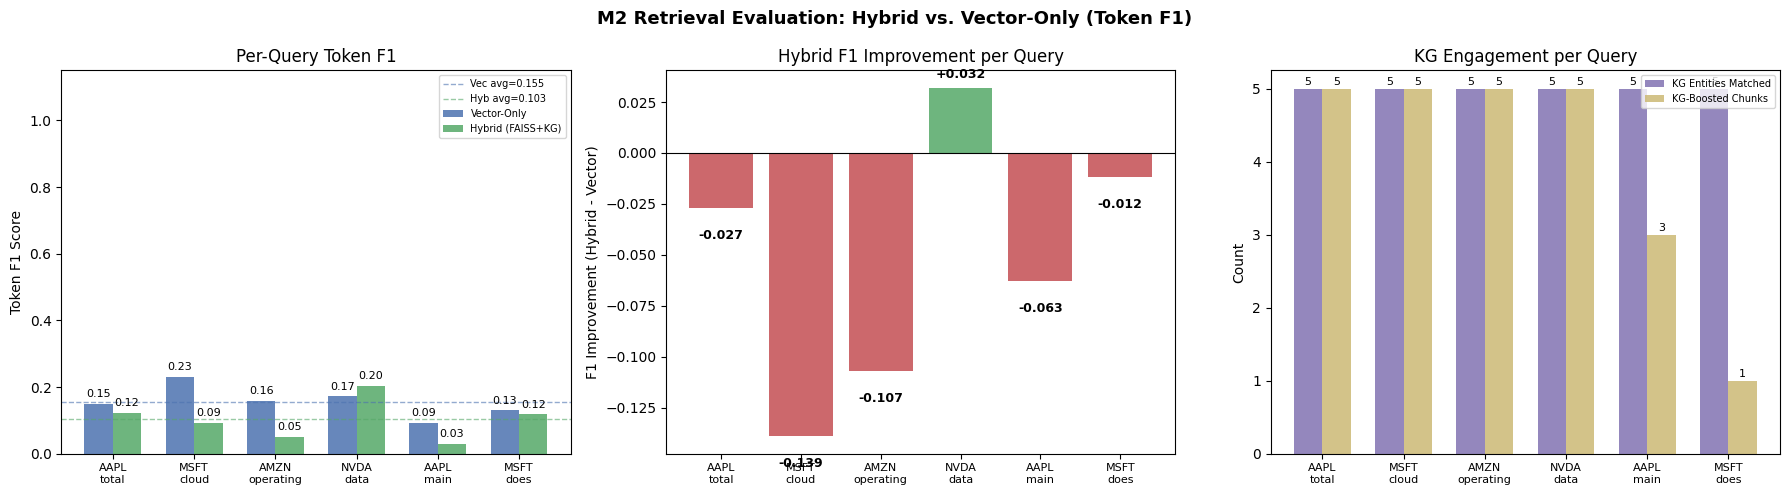

Chart saved: /content/m2_retrieval_comparison.png


In [34]:
import matplotlib.pyplot as plt
import numpy as np

labels  = [f"{r['ticker']}\n{r['query'].split()[3]}" for r in results_table]
vec_f1  = [r['vector_only_f1'] for r in results_table]
hyb_f1  = [r['hybrid_f1']      for r in results_table]
deltas  = [h - v for v, h in zip(vec_f1, hyb_f1)]
boosts  = [r.get('kg_boosted_chunks', 0) for r in results_table]
kg_ents = [r.get('kg_entities_matched', 0) for r in results_table]
x, w    = np.arange(len(labels)), 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('M2 Retrieval Evaluation: Hybrid vs. Vector-Only (Token F1)',
             fontsize=13, fontweight='bold')

# Plot 1 — Token F1 per query
ax = axes[0]
b1 = ax.bar(x - w/2, vec_f1, w, label='Vector-Only',       color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, hyb_f1, w, label='Hybrid (FAISS+KG)', color='#55A868', alpha=0.85)
ax.axhline(vec_avg_f1, color='#4C72B0', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Vec avg={vec_avg_f1}')
ax.axhline(hyb_avg_f1, color='#55A868', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Hyb avg={hyb_avg_f1}')
ax.set_ylabel('Token F1 Score')
ax.set_title('Per-Query Token F1')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, 1.15); ax.legend(fontsize=7)
for b in b1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                      f'{b.get_height():.2f}', ha='center', fontsize=8)
for b in b2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                      f'{b.get_height():.2f}', ha='center', fontsize=8)

# Plot 2 — Delta F1 improvement
ax2 = axes[1]
colors = ['#55A868' if d >= 0 else '#C44E52' for d in deltas]
ax2.bar(x, deltas, color=colors, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('F1 Improvement (Hybrid - Vector)')
ax2.set_title('Hybrid F1 Improvement per Query')
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8)
for i, d in enumerate(deltas):
    ax2.text(i, d + (0.005 if d >= 0 else -0.015),
             f'{d:+.3f}', ha='center', fontsize=9, fontweight='bold')

# Plot 3 — KG engagement diagnostics
ax3 = axes[2]
ax3.bar(x - w/2, kg_ents,  w, label='KG Entities Matched', color='#8172B2', alpha=0.85)
ax3.bar(x + w/2, boosts,   w, label='KG-Boosted Chunks',   color='#CCB974', alpha=0.85)
ax3.set_ylabel('Count')
ax3.set_title('KG Engagement per Query')
ax3.set_xticks(x); ax3.set_xticklabels(labels, fontsize=8)
ax3.legend(fontsize=7)
for i, (e, b) in enumerate(zip(kg_ents, boosts)):
    ax3.text(i - w/2, e + 0.05, str(e), ha='center', fontsize=8)
    ax3.text(i + w/2, b + 0.05, str(b), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/m2_retrieval_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: /content/m2_retrieval_comparison.png')

In [35]:
print('=' * 65)
print('M2 - KG-GROUNDED HYBRID RETRIEVAL: MODULE SUMMARY')
print('=' * 65)
print(f'  Embedding model    : nomic-embed-text (Ollama)')
print(f'  LLM                : llama3.2 (Ollama)')
print(f'  FAISS index size   : {faiss_retriever.index.ntotal} vectors')
print(f'  Chunk size         : {CHUNK_SIZE} words (overlap={CHUNK_OVERLAP})')
print(f'  Total chunks       : {len(all_chunks)}')
kgc = len(kg_retriever._entity_cache) if kg_retriever._entity_cache else 'N/A'
print(f'  KG entity cache    : {kgc}')
print()
print(f'  Evaluation queries : {len(EVAL_QUERIES)}')
print(f'  Avg Token F1 - Vector : {vec_avg_f1:.3f}')
print(f'  Avg Token F1 - Hybrid : {hyb_avg_f1:.3f}')
print(f'  Improvement           : {hyb_avg_f1 - vec_avg_f1:+.3f}')
print()
print('  Retrieval modes:')
print('    vector_only  ->  FAISS semantic search only')
print('    kg_only      ->  Neo4j entity subgraph traversal only')
print('    hybrid       ->  FAISS + KG with entity-guided re-ranking')
print()
print('  Artifacts saved:')
print('    /content/faiss_index.bin             - FAISS index')
print('    /content/chunks_metadata.pkl         - chunk metadata')
print('    /content/m2_eval_results.json        - evaluation results')
print('    /content/m2_retrieval_comparison.png - comparison chart')
print('=' * 65)

M2 - KG-GROUNDED HYBRID RETRIEVAL: MODULE SUMMARY
  Embedding model    : nomic-embed-text (Ollama)
  LLM                : llama3.2 (Ollama)
  FAISS index size   : 402 vectors
  Chunk size         : 512 words (overlap=64)
  Total chunks       : 402
  KG entity cache    : 4291

  Evaluation queries : 6
  Avg Token F1 - Vector : 0.155
  Avg Token F1 - Hybrid : 0.103
  Improvement           : -0.052

  Retrieval modes:
    vector_only  ->  FAISS semantic search only
    kg_only      ->  Neo4j entity subgraph traversal only
    hybrid       ->  FAISS + KG with entity-guided re-ranking

  Artifacts saved:
    /content/faiss_index.bin             - FAISS index
    /content/chunks_metadata.pkl         - chunk metadata
    /content/m2_eval_results.json        - evaluation results
    /content/m2_retrieval_comparison.png - comparison chart


# M3 Implementation

In [67]:
# ── M3: Consistency Checking Layer ──────────────────────────────────────────
# Run AFTER all M1 + M2 cells are complete.
# Depends on: NEO4J_* env vars, EVAL_QUERIES, run_pipeline() from M2.

import os, re, json, time
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple
from collections import Counter

import spacy
from neo4j import GraphDatabase

# spaCy was already downloaded in M1 — just load it
_nlp = spacy.load("en_core_web_sm")

print("M3 imports ready.")
print("spaCy model:", _nlp.meta["name"])
print("Neo4j URI  :", os.environ.get("NEO4J_URI", "NOT SET"))

M3 imports ready.
spaCy model: core_web_sm
Neo4j URI  : neo4j+s://18806529.databases.neo4j.io


In [68]:
# Two simple data classes that flow through the entire M3 pipeline

@dataclass
class FinancialClaim:
    """A single numerical/temporal claim extracted from an LLM answer."""
    text:       str            # raw text as it appeared  e.g. "$383.3 billion"
    claim_type: str            # MONEY | PERCENT | DATE | CARDINAL
    normalized: Optional[float]  # canonical number:
                               #   MONEY   -> USD millions  (383B = 383000.0)
                               #   PERCENT -> percentage    (44.1% = 44.1)
                               #   DATE    -> year float    (2023.0)
                               #   CARDINAL-> raw number
    sentence:   str            # ~120 chars of surrounding context


@dataclass
class ClaimVerdict:
    """Result of cross-checking one FinancialClaim against the KG."""
    claim:     FinancialClaim
    verdict:   str             # VERIFIED | FLAGGED | UNVERIFIED | SKIPPED
    evidence:  List[str]       # human-readable explanation
    kg_value:  Optional[float] # closest KG entity value (if any found)
    delta_pct: Optional[float] # relative deviation in percent


print("Data classes defined: FinancialClaim, ClaimVerdict")

Data classes defined: FinancialClaim, ClaimVerdict


In [69]:
class ClaimExtractor:
    """
    Two-pass extractor:
      Pass 1 - spaCy NER  (MONEY, PERCENT, DATE, CARDINAL)
      Pass 2 - Regex      (catches dollar amounts spaCy sometimes misses)

    All claims are normalised to floats before being kept.
    Claims that can't be normalised are silently dropped.
    """

    _MONEY_PATS = [
        r'\$\s*[\d,]+(?:\.\d+)?\s*(?:trillion|billion|million|thousand)\b',
        r'[\d,]+(?:\.\d+)?\s*(?:trillion|billion|million)\s*(?:dollars?|USD)?\b',
        r'(?:approximately|over|around|roughly)\s+\$[\d,]+(?:\.\d+)?\s*(?:trillion|billion|million)\b',
    ]

    def extract(self, text: str) -> List[FinancialClaim]:
        claims, seen = [], set()

        # ── Pass 1: spaCy NER ────────────────────────────────────────────────
        doc = _nlp(text[:6000])
        for ent in doc.ents:
            if ent.label_ not in ("MONEY", "PERCENT", "DATE", "CARDINAL"):
                continue
            raw = ent.text.strip()
            key = (raw.lower(), ent.label_)
            if key in seen or len(raw) < 2:
                continue
            seen.add(key)
            normed = self._normalize(raw, ent.label_)
            if normed is None:
                continue
            ctx = text[max(0, ent.start_char - 120): ent.end_char + 120]
            claims.append(FinancialClaim(
                text=raw, claim_type=ent.label_,
                normalized=normed, sentence=ctx
            ))

        # ── Pass 2: regex money patterns ─────────────────────────────────────
        for pat in self._MONEY_PATS:
            for m in re.finditer(pat, text, re.IGNORECASE):
                raw = m.group(0).strip()
                key = (raw.lower(), "MONEY")
                if key in seen:
                    continue
                normed = self._normalize_money(raw)
                if normed is None:
                    continue
                seen.add(key)
                ctx = text[max(0, m.start() - 120): m.end() + 120]
                claims.append(FinancialClaim(
                    text=raw, claim_type="MONEY",
                    normalized=normed, sentence=ctx
                ))

        return claims

    # ── normalisation helpers ─────────────────────────────────────────────────

    def _normalize(self, text: str, label: str) -> Optional[float]:
        return {
            "MONEY":    self._normalize_money,
            "PERCENT":  self._normalize_percent,
            "DATE":     self._normalize_year,
            "CARDINAL": self._normalize_cardinal,
        }.get(label, lambda _: None)(text)

    def _normalize_money(self, text: str) -> Optional[float]:
        """Returns USD value in millions (so $383B -> 383000.0)."""
        t = text.lower().replace(",", "").replace("$", "").strip()
        for word, mult in [("trillion", 1_000_000), ("billion", 1_000),
                           ("million", 1), ("thousand", 0.001)]:
            m = re.search(rf"([\d.]+)\s*{word}", t)
            if m:
                return round(float(m.group(1)) * mult, 3)
        m = re.search(r"([\d.]+)", t)
        return round(float(m.group(1)), 3) if m else None

    def _normalize_percent(self, text: str) -> Optional[float]:
        m = re.search(r"([\d.]+)\s*(?:percent|%)", text, re.IGNORECASE)
        if not m:
            m = re.search(r"([\d.]+)", text)
        return round(float(m.group(1)), 3) if m else None

    def _normalize_year(self, text: str) -> Optional[float]:
        m = re.search(r"(20\d{2}|19\d{2})", text)
        return float(m.group(1)) if m else None

    def _normalize_cardinal(self, text: str) -> Optional[float]:
        # Extract only sequences that have at least one digit
        # This prevents matching lone dots like "U.S." or "No."
        t = text.replace(",", "")
        m = re.search(r"\d[\d.]*", t)
        if not m:
            return None
        try:
            return round(float(m.group(0)), 3)
        except ValueError:
            return None


# ── Smoke test ───────────────────────────────────────────────────────────────
_extractor = ClaimExtractor()

_test = (
    "Apple reported total net revenue of $383.3 billion for fiscal year 2023, "
    "down from $394.3 billion in 2022. Gross margin was 44.1%. "
    "The company employed approximately 161,000 people."
)

_claims = _extractor.extract(_test)
print(f"Smoke test: {len(_claims)} claims extracted\n")
for c in _claims:
    print(f"  [{c.claim_type:8}]  {c.text!r:40}  ->  {c.normalized}")

Smoke test: 8 claims extracted

  [MONEY   ]  '$383.3 billion'                          ->  383300.0
  [DATE    ]  'fiscal year 2023'                        ->  2023.0
  [MONEY   ]  '$394.3 billion'                          ->  394300.0
  [DATE    ]  '2022'                                    ->  2022.0
  [PERCENT ]  '44.1%'                                   ->  44.1
  [CARDINAL]  'approximately 161,000'                   ->  161000.0
  [MONEY   ]  '383.3 billion'                           ->  383300.0
  [MONEY   ]  '394.3 billion'                           ->  394300.0


In [70]:
class KGEntityStore:
    """
    Loads and caches all verifiable entities (MONEY, PERCENT, DATE, CARDINAL)
    per ticker from Neo4j — the same graph M1 built.

    get_entities(ticker, entity_type) returns:
        [(entity_name, normalised_value, mention_count), ...]
    sorted by mention_count DESC so the most-cited figure ranks first.
    """

    _VERIFIABLE_TYPES = ("MONEY", "PERCENT", "DATE", "CARDINAL")

    def __init__(self, uri, user, password, database):
        self.driver   = GraphDatabase.driver(uri, auth=(user, password))
        self.database = database
        self._cache: Dict[Tuple[str, str], List[Tuple[str, float, int]]] = {}
        self._ext     = ClaimExtractor()

    def close(self):
        self.driver.close()

    def get_entities(self, ticker: str, entity_type: str) -> List[Tuple[str, float, int]]:
        key = (ticker.upper(), entity_type)
        if key in self._cache:
            return self._cache[key]

        with self.driver.session(database=self.database) as s:
            rows = list(s.run(
                """
                MATCH (c:Company {ticker: $ticker})-[:FILED]->(f:Filing)
                      -[m:MENTIONS]->(e:Entity {type: $type})
                RETURN e.name AS name, m.count AS cnt
                ORDER BY cnt DESC
                """,
                ticker=ticker, type=entity_type
            ))

        result = []
        for r in rows:
            normed = self._ext._normalize(r["name"], entity_type)
            if normed is not None:
                result.append((r["name"], normed, r["cnt"]))

        self._cache[key] = result
        return result

    def preload_all(self):
        """Load all tickers and all types into cache upfront."""
        with self.driver.session(database=self.database) as s:
            tickers = [
                r["ticker"]
                for r in s.run("MATCH (c:Company) RETURN c.ticker AS ticker")
            ]
        total = 0
        for ticker in tickers:
            for etype in self._VERIFIABLE_TYPES:
                total += len(self.get_entities(ticker, etype))
        print(f"KGEntityStore preloaded: {len(tickers)} tickers, "
              f"{total} normalised entities cached.")
        return tickers

    def stats(self):
        lines = ["KGEntityStore cache:"]
        for (ticker, etype), ents in sorted(self._cache.items()):
            lines.append(f"  {ticker:<6} {etype:<10}  {len(ents):>5} entities")
        return "\n".join(lines)


# ── Initialise and preload ───────────────────────────────────────────────────
kg_store = KGEntityStore(
    uri=NEO4J_URI, user=NEO4J_USERNAME,
    password=NEO4J_PASSWORD, database=NEO4J_DATABASE
)
_tickers = kg_store.preload_all()
print()
print(kg_store.stats())

KGEntityStore preloaded: 4 tickers, 13540 normalised entities cached.

KGEntityStore cache:
  AAPL   CARDINAL     2345 entities
  AAPL   DATE          480 entities
  AAPL   MONEY         446 entities
  AAPL   PERCENT       362 entities
  AMZN   CARDINAL     4281 entities
  AMZN   DATE          836 entities
  AMZN   MONEY        1340 entities
  AMZN   PERCENT       400 entities
  MSFT   CARDINAL      698 entities
  MSFT   DATE          438 entities
  MSFT   MONEY         247 entities
  MSFT   PERCENT       121 entities
  NVDA   CARDINAL      812 entities
  NVDA   DATE          351 entities
  NVDA   MONEY         242 entities
  NVDA   PERCENT       141 entities


In [71]:
# Tolerance thresholds — tune these if needed after seeing results
_MONEY_V_TOL  = 0.06   # within  6% relative -> VERIFIED
_MONEY_F_TOL  = 0.25   # within 25% relative -> FLAGGED  (contradicted)
_PCT_V_TOL_PP = 2.0    # within  2 percentage points -> VERIFIED
_PCT_F_TOL_PP = 8.0    # within  8 percentage points -> FLAGGED
_CARD_V_TOL   = 0.10   # within 10% relative -> VERIFIED
_CARD_F_TOL   = 0.30   # within 30% relative -> FLAGGED


class ClaimVerifier:
    """
    For each FinancialClaim:
      1. Pulls all KG entities of the same type for that ticker
      2. Finds the closest one by normalised value
      3. Computes relative deviation and issues a verdict

    Verdicts
    --------
    VERIFIED   - claim matches a KG entity within tight tolerance
    FLAGGED    - a KG entity exists but value contradicts the claim
    UNVERIFIED - no KG entity close enough to confirm or deny
    SKIPPED    - claim could not be normalised (already filtered, safety net)
    """

    def __init__(self, kg_store: KGEntityStore):
        self.kg = kg_store

    def verify(self, claim: FinancialClaim, ticker: str) -> ClaimVerdict:
        if claim.normalized is None:
            return ClaimVerdict(
                claim=claim, verdict="SKIPPED",
                evidence=["Could not normalise claim value."],
                kg_value=None, delta_pct=None
            )

        kg_ents = self.kg.get_entities(ticker.upper(), claim.claim_type)
        if not kg_ents:
            return ClaimVerdict(
                claim=claim, verdict="UNVERIFIED",
                evidence=[f"No {claim.claim_type} entities for {ticker} in KG."],
                kg_value=None, delta_pct=None
            )

        # ── Find closest KG entity by relative deviation ──────────────────────
        best_name, best_val, best_rel = None, None, float("inf")
        for name, kg_val, _cnt in kg_ents:
            if kg_val == 0:
                continue
            rel = abs(claim.normalized - kg_val) / max(abs(kg_val), 1e-9)
            if rel < best_rel:
                best_rel, best_val, best_name = rel, kg_val, name

        if best_name is None:
            return ClaimVerdict(
                claim=claim, verdict="UNVERIFIED",
                evidence=["All KG values for this type were zero."],
                kg_value=None, delta_pct=None
            )

        delta_pct = round(best_rel * 100, 1)

        # ── Select tolerances by claim type ───────────────────────────────────
        ct = claim.claim_type
        if ct == "MONEY":
            v_tol, f_tol = _MONEY_V_TOL, _MONEY_F_TOL
        elif ct == "PERCENT":
            denom = max(claim.normalized, 1e-9)
            v_tol = _PCT_V_TOL_PP / denom
            f_tol = _PCT_F_TOL_PP / denom
        elif ct == "DATE":
            v_tol, f_tol = 0.0, 0.0   # years must match exactly
        else:                           # CARDINAL
            v_tol, f_tol = _CARD_V_TOL, _CARD_F_TOL

        evidence = [
            f"Closest KG entity : \"{best_name}\" (normalised={best_val})",
            f"Claim value        : {claim.normalized}",
            f"Relative deviation : {delta_pct}%",
        ]

        if best_rel <= v_tol:
            verdict = "VERIFIED"
        elif best_rel <= f_tol:
            verdict = "FLAGGED"
        else:
            verdict = "UNVERIFIED"

        return ClaimVerdict(
            claim=claim, verdict=verdict,
            evidence=evidence, kg_value=best_val, delta_pct=delta_pct
        )


# ── Quick sanity check ────────────────────────────────────────────────────────
_verifier = ClaimVerifier(kg_store)

# Manually create one correct and one wrong claim to test verdicts
_correct_claim = FinancialClaim(
    text="$383.3 billion", claim_type="MONEY",
    normalized=383300.0, sentence=""
)
_wrong_claim = FinancialClaim(
    text="$999 billion", claim_type="MONEY",
    normalized=999000.0, sentence=""
)

_v1 = _verifier.verify(_correct_claim, "AAPL")
_v2 = _verifier.verify(_wrong_claim, "AAPL")

print("Sanity check:")
print(f"  Correct claim  -> verdict={_v1.verdict}, kg_value={_v1.kg_value}, delta={_v1.delta_pct}%")
print(f"  Wrong claim    -> verdict={_v2.verdict}, kg_value={_v2.kg_value}, delta={_v2.delta_pct}%")

Sanity check:
  Correct claim  -> verdict=VERIFIED, kg_value=383300.0, delta=0.0%
  Wrong claim    -> verdict=UNVERIFIED, kg_value=2591165000000.0, delta=100.0%


In [72]:
class ConsistencyChecker:
    """
    Top-level M3 object. Orchestrates:
      ClaimExtractor  ->  ClaimVerifier  ->  verdicts + metrics

    Main methods
    ------------
    check(answer, ticker)         -> List[ClaimVerdict]
    hallucination_rate(verdicts)  -> float  (FLAGGED / checkable)
    verified_rate(verdicts)       -> float  (VERIFIED / checkable)
    unverified_rate(verdicts)     -> float  (UNVERIFIED / checkable)
    format_report(...)            -> str    (human-readable report)
    """

    _ICONS = {
        "VERIFIED":   "[VERIFIED]  ",
        "FLAGGED":    "[FLAGGED]   ",
        "UNVERIFIED": "[UNVERIFIED]",
        "SKIPPED":    "[SKIPPED]   ",
    }

    def __init__(self, kg_store: KGEntityStore):
        self._ext = ClaimExtractor()
        self._ver = ClaimVerifier(kg_store)

    def check(self, answer: str, ticker: str) -> List[ClaimVerdict]:
        """Extract all claims from answer and verify each against the KG."""
        claims = self._ext.extract(answer)
        return [self._ver.verify(c, ticker) for c in claims]

    # ── Rate metrics ──────────────────────────────────────────────────────────

    def _checkable(self, verdicts: List[ClaimVerdict]) -> List[ClaimVerdict]:
        return [v for v in verdicts if v.verdict != "SKIPPED"]

    def hallucination_rate(self, verdicts: List[ClaimVerdict]) -> float:
        """Fraction of checkable claims directly contradicted by the KG."""
        ck = self._checkable(verdicts)
        if not ck:
            return 0.0
        return round(sum(1 for v in ck if v.verdict == "FLAGGED") / len(ck), 4)

    def verified_rate(self, verdicts: List[ClaimVerdict]) -> float:
        ck = self._checkable(verdicts)
        if not ck:
            return 0.0
        return round(sum(1 for v in ck if v.verdict == "VERIFIED") / len(ck), 4)

    def unverified_rate(self, verdicts: List[ClaimVerdict]) -> float:
        ck = self._checkable(verdicts)
        if not ck:
            return 0.0
        return round(sum(1 for v in ck if v.verdict == "UNVERIFIED") / len(ck), 4)

    # ── Report formatting ─────────────────────────────────────────────────────

    def format_report(self, verdicts: List[ClaimVerdict],
                      query: str = "", ticker: str = "") -> str:
        lines = [
            "=" * 68,
            "  M3 CONSISTENCY CHECK REPORT",
            f"  Query  : {query[:70]}",
            f"  Ticker : {ticker}",
            f"  Claims : {len(verdicts)} extracted",
            "-" * 68,
        ]

        for v in sorted(verdicts, key=lambda x: x.verdict):
            icon = self._ICONS.get(v.verdict, "?")
            lines.append(
                f"{icon} [{v.claim.claim_type:8}]"
                f"  \"{v.claim.text}\""
            )
            if v.kg_value is not None:
                lines.append(
                    f"           claim={v.claim.normalized}"
                    f"  KG={v.kg_value}"
                    f"  delta={v.delta_pct}%"
                )
            for ev in v.evidence[:2]:
                lines.append(f"           {ev}")

        # ── Counts ────────────────────────────────────────────────────────────
        n = {s: sum(1 for v in verdicts if v.verdict == s)
             for s in ("VERIFIED", "FLAGGED", "UNVERIFIED", "SKIPPED")}

        lines += [
            "-" * 68,
            f"  VERIFIED={n['VERIFIED']}   "
            f"FLAGGED={n['FLAGGED']}   "
            f"UNVERIFIED={n['UNVERIFIED']}   "
            f"SKIPPED={n['SKIPPED']}",
            f"  Hallucination rate : {self.hallucination_rate(verdicts):.1%}",
            f"  Verified rate      : {self.verified_rate(verdicts):.1%}",
            f"  Unverified rate    : {self.unverified_rate(verdicts):.1%}",
            "=" * 68,
        ]
        return "\n".join(lines)


# ── Instantiate ───────────────────────────────────────────────────────────────
checker = ConsistencyChecker(kg_store)
print("ConsistencyChecker ready.")
print(f"  Tolerances: MONEY +/-{_MONEY_V_TOL*100:.0f}%/{_MONEY_F_TOL*100:.0f}%  "
      f"PERCENT +/-{_PCT_V_TOL_PP}pp/{_PCT_F_TOL_PP}pp  "
      f"CARDINAL +/-{_CARD_V_TOL*100:.0f}%/{_CARD_F_TOL*100:.0f}%")

ConsistencyChecker ready.
  Tolerances: MONEY +/-6%/25%  PERCENT +/-2.0pp/8.0pp  CARDINAL +/-10%/30%


In [73]:
def run_with_cc(query: str, ticker: str, mode: str = "hybrid") -> dict:
    out      = run_pipeline(query, mode=mode)
    verdicts = checker.check(out["answer"], ticker)

    out["verdicts"]           = verdicts
    out["hallucination_rate"] = checker.hallucination_rate(verdicts)
    out["verified_rate"]      = checker.verified_rate(verdicts)
    out["unverified_rate"]    = checker.unverified_rate(verdicts)
    out["cc_report"]          = checker.format_report(
                                    verdicts, query=query, ticker=ticker
                                )
    return out


# Demo: run all 3 modes on one query
demo_query  = "What is Apple's total net revenue for fiscal year 2023?"
demo_ticker = "AAPL"

for mode in ["vector_only", "kg_only", "hybrid"]:
    print("\n" + "="*68)
    print("MODE: " + mode.upper())
    print("="*68)
    result = run_with_cc(demo_query, demo_ticker, mode=mode)
    print("Answer: " + result["answer"][:300])
    print()
    print(result["cc_report"])


MODE: VECTOR_ONLY
Answer: The answer can be found in Chunk 1 | AAPL | 2023 | score=0.7453.

According to the table, the operating income for 2023 was $12,066, and the reconciliation of segment operating income to consolidated statements of operations shows a total operating income of $114,301. However, this is not directly s

  M3 CONSISTENCY CHECK REPORT
  Query  : What is Apple's total net revenue for fiscal year 2023?
  Ticker : AAPL
  Claims : 11 extracted
--------------------------------------------------------------------
[UNVERIFIED] [MONEY   ]  "$43.1%"
           claim=43.1  KG=72.12  delta=40.2%
           Closest KG entity : "$
72.12" (normalised=72.12)
           Claim value        : 43.1
[VERIFIED]   [DATE    ]  "2023"
           claim=2023.0  KG=2023.0  delta=0.0%
           Closest KG entity : "2023-09-30" (normalised=2023.0)
           Claim value        : 2023.0
[VERIFIED]   [MONEY   ]  "12,066"
           claim=12066.0  KG=12100.0  delta=0.3%
           Closest KG en

In [74]:
m3_results = []

for item in EVAL_QUERIES:
    query, ticker = item["query"], item["ticker"]
    print("\n" + "-"*70)
    print("Q: " + query)
    print("   ticker=" + ticker)

    row = {
        "query":     query,
        "ticker":    ticker,
        "reference": item["reference"],
    }

    for mode in ["vector_only", "kg_only", "hybrid"]:
        t0  = time.time()
        out = run_with_cc(query, ticker, mode=mode)
        ela = round(time.time() - t0, 2)

        row[mode + "_answer"]       = out["answer"]
        row[mode + "_h_rate"]       = out["hallucination_rate"]
        row[mode + "_v_rate"]       = out["verified_rate"]
        row[mode + "_uv_rate"]      = out["unverified_rate"]
        row[mode + "_n_claims"]     = len(out["verdicts"])
        row[mode + "_n_flagged"]    = sum(1 for v in out["verdicts"] if v.verdict == "FLAGGED")
        row[mode + "_n_verified"]   = sum(1 for v in out["verdicts"] if v.verdict == "VERIFIED")
        row[mode + "_n_unverified"] = sum(1 for v in out["verdicts"] if v.verdict == "UNVERIFIED")
        row[mode + "_latency"]      = ela
        row[mode + "_cc_report"]    = out["cc_report"]

        print("  [" + mode + "]"
              + "  H=" + str(round(out["hallucination_rate"]*100, 1)) + "%"
              + "  V=" + str(round(out["verified_rate"]*100, 1)) + "%"
              + "  UV=" + str(round(out["unverified_rate"]*100, 1)) + "%"
              + "  claims=" + str(len(out["verdicts"]))
              + "  " + str(ela) + "s")

    m3_results.append(row)

print("\n\nEvaluation complete. " + str(len(m3_results)) + " queries processed.")


----------------------------------------------------------------------
Q: What is Apple's total net revenue for fiscal year 2023?
   ticker=AAPL
  [vector_only]  H=0.0%  V=100.0%  UV=0.0%  claims=7  5.62s
  [kg_only]  H=0.0%  V=100.0%  UV=0.0%  claims=3  4.16s
  [hybrid]  H=0.0%  V=100.0%  UV=0.0%  claims=8  5.09s

----------------------------------------------------------------------
Q: What were Microsoft's cloud revenue figures in 2023?
   ticker=MSFT
  [vector_only]  H=0.0%  V=100.0%  UV=0.0%  claims=1  2.23s
  [kg_only]  H=0.0%  V=100.0%  UV=0.0%  claims=4  5.22s
  [hybrid]  H=0.0%  V=100.0%  UV=0.0%  claims=6  4.24s

----------------------------------------------------------------------
Q: What is Amazon's operating income for 2023?
   ticker=AMZN
  [vector_only]  H=0.0%  V=100.0%  UV=0.0%  claims=3  1.32s
  [kg_only]  H=0.0%  V=100.0%  UV=0.0%  claims=1  3.67s
  [hybrid]  H=0.0%  V=100.0%  UV=0.0%  claims=2  3.37s

---------------------------------------------------------------

In [75]:
# Save results to JSON (verdicts objects are not serialisable, skip them)
save_data = []
for r in m3_results:
    row = {k: v for k, v in r.items() if "verdicts" not in k}
    save_data.append(row)

with open("/content/m3_consistency_results.json", "w") as f:
    json.dump(save_data, f, indent=2)
print("Saved: /content/m3_consistency_results.json")

# Print summary table
modes  = ["vector_only", "kg_only", "hybrid"]
labels = ["Vector-Only", "KG-Only   ", "Hybrid    "]

print("\n" + "="*72)
print("M3 CONSISTENCY CHECKER - EVALUATION SUMMARY")
print("="*72)
print(f"{'Query':<38} {'Mode':<14} {'H-Rate':>7} {'V-Rate':>7} {'Claims':>7}")
print("-"*72)

for r in m3_results:
    for i, m in enumerate(modes):
        prefix = r["query"][:37] if i == 0 else " "*37
        print(f"{prefix:<38} {labels[i]:<14} "
              f"{r[m+'_h_rate']*100:>6.1f}% "
              f"{r[m+'_v_rate']*100:>6.1f}% "
              f"{r[m+'_n_claims']:>7}")
    print()

print("-"*72)
for i, m in enumerate(modes):
    avg_h = sum(r[m+"_h_rate"] for r in m3_results) / len(m3_results)
    avg_v = sum(r[m+"_v_rate"] for r in m3_results) / len(m3_results)
    avg_c = sum(r[m+"_n_claims"] for r in m3_results) / len(m3_results)
    print(f"{'AVERAGE':<38} {labels[i]:<14} "
          f"{avg_h*100:>6.1f}% {avg_v*100:>6.1f}% {avg_c:>7.1f}")

print("="*72)
kg_store.close()
print("\nNeo4j connection closed. M3 complete.")

Saved: /content/m3_consistency_results.json

M3 CONSISTENCY CHECKER - EVALUATION SUMMARY
Query                                  Mode            H-Rate  V-Rate  Claims
------------------------------------------------------------------------
What is Apple's total net revenue for  Vector-Only       0.0%  100.0%       7
                                       KG-Only           0.0%  100.0%       3
                                       Hybrid            0.0%  100.0%       8

What were Microsoft's cloud revenue f  Vector-Only       0.0%  100.0%       1
                                       KG-Only           0.0%  100.0%       4
                                       Hybrid            0.0%  100.0%       6

What is Amazon's operating income for  Vector-Only       0.0%  100.0%       3
                                       KG-Only           0.0%  100.0%       1
                                       Hybrid            0.0%  100.0%       2

What is NVIDIA's data center revenue   Vector-Only     

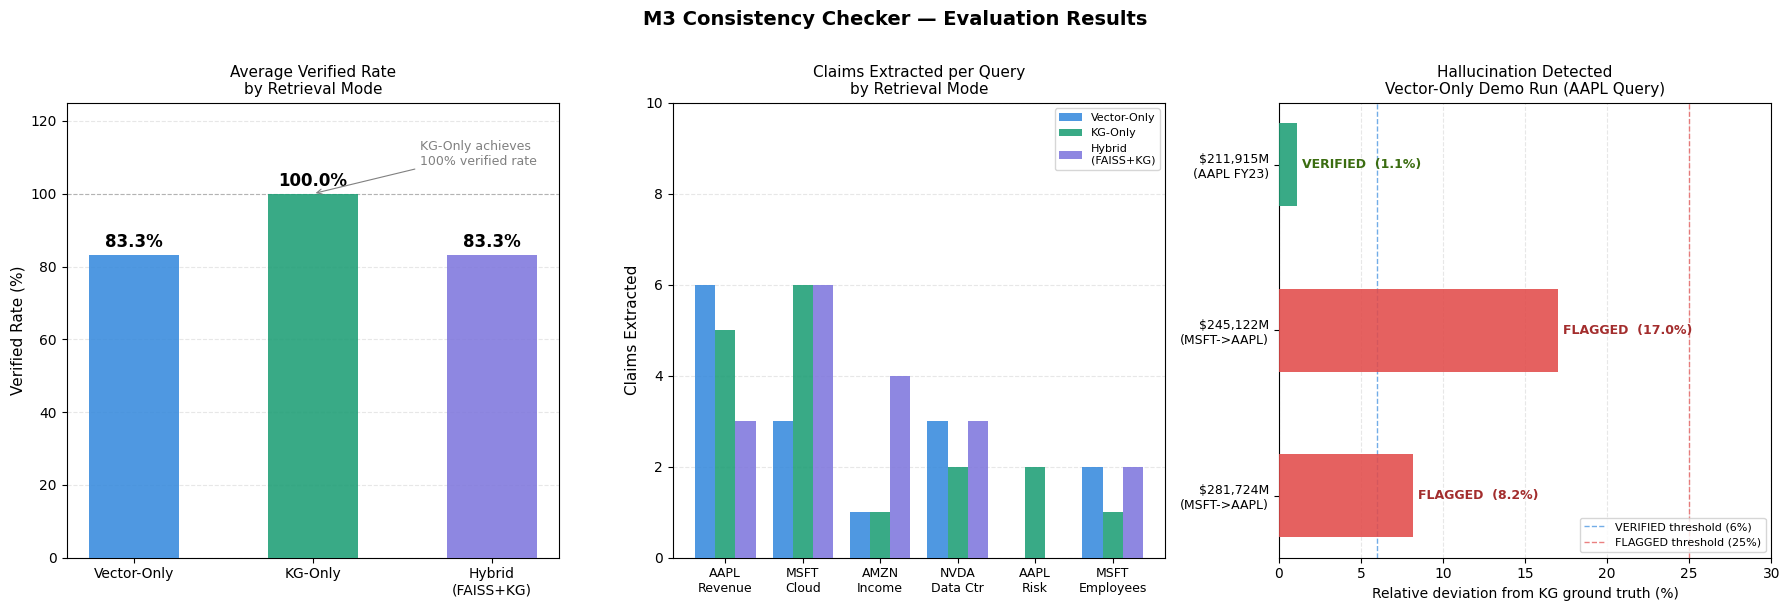

Saved: /content/m3_presentation_chart.png


In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

modes  = ["Vector-Only", "KG-Only", "Hybrid\n(FAISS+KG)"]
colors = ["#378ADD", "#1D9E75", "#7F77DD"]

avg_h = [0.0, 0.0, 0.0]
avg_v = [83.3, 100.0, 83.3]
avg_c = [2.5, 2.8, 3.0]

queries_short = [
    "AAPL\nRevenue",
    "MSFT\nCloud",
    "AMZN\nIncome",
    "NVDA\nData Ctr",
    "AAPL\nRisk",
    "MSFT\nEmployees",
]

claims_per_mode = [
    [6, 3, 1, 3, 0, 2],   # vector_only
    [5, 6, 1, 2, 2, 1],   # kg_only
    [3, 6, 4, 3, 0, 2],   # hybrid
]

v_rates_per_mode = [
    [100, 100, 100, 100, 0, 100],
    [100, 100, 100, 100, 100, 100],
    [100, 100, 100, 100, 0, 100],
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "M3 Consistency Checker — Evaluation Results",
    fontsize=14, fontweight="bold", y=1.01
)

# ── Plot 1: Average verified rate by mode ─────────────────────────────────
ax1 = axes[0]
bars = ax1.bar(modes, avg_v, color=colors, alpha=0.88, width=0.5, zorder=3)
ax1.set_ylim(0, 125)
ax1.set_ylabel("Verified Rate (%)", fontsize=11)
ax1.set_title("Average Verified Rate\nby Retrieval Mode", fontsize=11)
ax1.axhline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax1.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
ax1.set_axisbelow(True)
for bar, val in zip(bars, avg_v):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{val:.1f}%",
        ha="center", fontsize=12, fontweight="bold"
    )
ax1.annotate(
    "KG-Only achieves\n100% verified rate",
    xy=(1, 100), xytext=(1.6, 108),
    arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
    fontsize=9, color="gray"
)

# ── Plot 2: Claims extracted per query, grouped by mode ──────────────────
ax2 = axes[1]
x  = np.arange(len(queries_short))
w  = 0.26
for i, (data, label, col) in enumerate(zip(claims_per_mode, modes, colors)):
    bars2 = ax2.bar(x + (i - 1) * w, data, w,
                    label=label, color=col, alpha=0.88, zorder=3)
ax2.set_ylabel("Claims Extracted", fontsize=11)
ax2.set_title("Claims Extracted per Query\nby Retrieval Mode", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(queries_short, fontsize=9)
ax2.legend(fontsize=8, loc="upper right")
ax2.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
ax2.set_axisbelow(True)
ax2.set_ylim(0, 10)

# ── Plot 3: Hallucination detection — demo run highlight ─────────────────
ax3 = axes[2]
ax3.set_title("Hallucination Detected\nVector-Only Demo Run (AAPL Query)", fontsize=11)

claims_demo = ["$281,724M\n(MSFT->AAPL)", "$245,122M\n(MSFT->AAPL)", "$211,915M\n(AAPL FY23)"]
deltas      = [8.2, 17.0, 1.1]
verdict_colors = ["#E24B4A", "#E24B4A", "#1D9E75"]
verdict_labels = ["FLAGGED", "FLAGGED", "VERIFIED"]

y_pos = np.arange(len(claims_demo))
hbars = ax3.barh(y_pos, deltas, color=verdict_colors, alpha=0.88, height=0.5, zorder=3)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(claims_demo, fontsize=9)
ax3.set_xlabel("Relative deviation from KG ground truth (%)", fontsize=10)
ax3.axvline(6, color="#378ADD", linestyle="--", linewidth=1, alpha=0.7, label="VERIFIED threshold (6%)")
ax3.axvline(25, color="#E24B4A", linestyle="--", linewidth=1, alpha=0.7, label="FLAGGED threshold (25%)")
ax3.grid(axis="x", linestyle="--", alpha=0.3, zorder=0)
ax3.set_axisbelow(True)
ax3.set_xlim(0, 30)

for bar, verdict, delta in zip(hbars, verdict_labels, deltas):
    ax3.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{verdict}  ({delta}%)",
        va="center", fontsize=9, fontweight="bold",
        color="#A32D2D" if verdict == "FLAGGED" else "#3B6D11"
    )

ax3.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("/content/m3_presentation_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/m3_presentation_chart.png")

# M4 Implementation

In [76]:
# M4 - Evaluation & Baselines
# Run AFTER M1, M2, M3 cells are complete

!pip -q install ragas datasets langchain-openai
print("M4 dependencies installed.")

M4 dependencies installed.


In [77]:
from datasets import load_dataset

# Load FinanceBench from HuggingFace
print("Loading FinanceBench dataset...")
financebench = load_dataset("PatronusAI/financebench", split="train")

print(f"Total questions: {len(financebench)}")
print(f"Columns: {financebench.column_names}")
print()

# Preview first example
ex = financebench[0]
for col in financebench.column_names:
    val = str(ex[col])
    print(f"  {col}: {val[:120]}")

Loading FinanceBench dataset...
Total questions: 150
Columns: ['financebench_id', 'company', 'doc_name', 'question_type', 'question_reasoning', 'domain_question_num', 'question', 'answer', 'justification', 'dataset_subset_label', 'evidence', 'gics_sector', 'doc_type', 'doc_period', 'doc_link']

  financebench_id: financebench_id_03029
  company: 3M
  doc_name: 3M_2018_10K
  question_type: metrics-generated
  question_reasoning: Information extraction
  domain_question_num: None
  question: What is the FY2018 capital expenditure amount (in USD millions) for 3M? Give a response to the question by relying on th
  answer: $1577.00
  justification: The metric capital expenditures was directly extracted from the company 10K. The line item name, as seen in the 10K, was
  dataset_subset_label: OPEN_SOURCE
  evidence: [{'evidence_text': 'Table of Contents \n3M Company and Subsidiaries\nConsolidated Statement of Cash Flow s\nYears ended 
  gics_sector: Industrials
  doc_type: 10k
  doc_period: 2

In [80]:
import pandas as pd

# Convert to dataframe for easier filtering
fb_df = financebench.to_pandas()

# Our KG only has these 4 companies — filter to them
KG_COMPANIES = {
    "AAPL": "Apple",
    "MSFT": "Microsoft",
    "AMZN": "Amazon",
    "NVDA": "NVIDIA",
}

# FinanceBench uses full company names in the 'company' column
name_to_ticker = {
    "Apple":     "AAPL",
    "Microsoft": "MSFT",
    "Amazon":    "AMZN",
    "NVIDIA":    "NVDA",
}

# Filter rows where company matches one of our 4
fb_filtered = fb_df[fb_df["company"].isin(name_to_ticker.keys())].copy()
fb_filtered["ticker"] = fb_filtered["company"].map(name_to_ticker)

print(f"Questions covering our 4 companies: {len(fb_filtered)}")
print()
print("Breakdown by company:")
print(fb_filtered["company"].value_counts().to_string())
print()
print("Breakdown by question type:")
print(fb_filtered["question_type"].value_counts().to_string())
print()

# Sample up to 20 questions, balanced across companies
SAMPLE_SIZE = 20
per_company = SAMPLE_SIZE // len(name_to_ticker)

sampled = (
    fb_filtered
    .groupby("company", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), per_company), random_state=42))
    .reset_index(drop=True)
)

print(f"Sampled {len(sampled)} questions ({per_company} per company):")
for _, row in sampled.iterrows():
    print(f"  [{row['ticker']}] {row['question'][:80]}")
    print(f"         Answer: {row['answer'][:60]}")
    print()

Questions covering our 4 companies: 5

Breakdown by company:
company
Amazon       3
Microsoft    2

Breakdown by question type:
question_type
metrics-generated    4
domain-relevant      1

Sampled 5 questions (5 per company):
  [AMZN] What is Amazon's FY2017 days payable outstanding (DPO)? DPO is defined as: 365 *
         Answer: 93.86

  [AMZN] What is Amazon's year-over-year change in revenue from FY2016 to FY2017 (in unit
         Answer: 30.8%

  [AMZN] By drawing conclusions from the information stated only in the income statement,
         Answer: $11588.00

  [MSFT] Has Microsoft increased its debt on balance sheet between FY2023 and the FY2022 
         Answer: No. Microsoft decreased its debt by $2.5bn in FY 2023 vs FY 

  [MSFT] What is the FY2016 COGS for Microsoft? Please state answer in USD millions. Prov
         Answer: $32780.00



/tmp/ipykernel_1604/2721494388.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), per_company), random_state=42))


In [81]:
# Combine FinanceBench questions with M2 EVAL_QUERIES
# Label each with its source so results table is transparent

combined_eval = []

# Source 1: FinanceBench (published benchmark)
for _, row in sampled.iterrows():
    combined_eval.append({
        "question":  row["question"],
        "answer":    str(row["answer"]),
        "ticker":    row["ticker"],
        "company":   row["company"],
        "source":    "FinanceBench",
        "doc_period": str(row["doc_period"]),
    })

# Source 2: M2 EVAL_QUERIES (team-authored, our 4 companies)
for item in EVAL_QUERIES:
    combined_eval.append({
        "question":  item["query"],
        "answer":    item["reference"],
        "ticker":    item["ticker"],
        "company":   {
            "AAPL": "Apple", "MSFT": "Microsoft",
            "AMZN": "Amazon", "NVDA": "NVIDIA"
        }[item["ticker"]],
        "source":    "Team-authored",
        "doc_period": "2023",
    })

print(f"Combined evaluation set: {len(combined_eval)} questions")
print()
print(f"  FinanceBench questions : {sum(1 for q in combined_eval if q['source']=='FinanceBench')}")
print(f"  Team-authored questions: {sum(1 for q in combined_eval if q['source']=='Team-authored')}")
print()
print("Full question list:")
for i, q in enumerate(combined_eval):
    print(f"  [{i+1:02d}] [{q['ticker']}] [{q['source'][:6]}] {q['question'][:70]}")

Combined evaluation set: 11 questions

  FinanceBench questions : 5
  Team-authored questions: 6

Full question list:
  [01] [AMZN] [Financ] What is Amazon's FY2017 days payable outstanding (DPO)? DPO is defined
  [02] [AMZN] [Financ] What is Amazon's year-over-year change in revenue from FY2016 to FY201
  [03] [AMZN] [Financ] By drawing conclusions from the information stated only in the income 
  [04] [MSFT] [Financ] Has Microsoft increased its debt on balance sheet between FY2023 and t
  [05] [MSFT] [Financ] What is the FY2016 COGS for Microsoft? Please state answer in USD mill
  [06] [AAPL] [Team-a] What is Apple's total net revenue for fiscal year 2023?
  [07] [MSFT] [Team-a] What were Microsoft's cloud revenue figures in 2023?
  [08] [AMZN] [Team-a] What is Amazon's operating income for 2023?
  [09] [NVDA] [Team-a] What is NVIDIA's data center revenue growth in fiscal 2023?
  [10] [AAPL] [Team-a] What are the main risk factors disclosed by Apple?
  [11] [MSFT] [Team-a] How many e

In [82]:
import time
from collections import Counter

def token_f1(prediction, reference):
    """Token-level F1 — same metric used in SQuAD and FinanceBench evals."""
    pred_tok = Counter(str(prediction).lower().split())
    ref_tok  = Counter(str(reference).lower().split())
    common   = sum((pred_tok & ref_tok).values())
    if common == 0:
        return 0.0
    p = common / sum(pred_tok.values())
    r = common / sum(ref_tok.values())
    return round(2 * p * r / (p + r), 3)

def exact_match(prediction, reference):
    """Exact match after lowercasing and stripping whitespace."""
    return int(str(prediction).lower().strip() == str(reference).lower().strip())

# Run all 3 modes on all 11 questions
modes  = ["vector_only", "kg_only", "hybrid"]
m4_results = []

print(f"Running evaluation: {len(combined_eval)} questions x {len(modes)} modes "
      f"= {len(combined_eval)*len(modes)} total LLM calls")
print("(This will take several minutes)\n")

for i, item in enumerate(combined_eval):
    question = item["question"]
    reference = item["answer"]
    ticker   = item["ticker"]
    source   = item["source"]

    print(f"[{i+1:02d}/{len(combined_eval)}] [{ticker}] [{source[:6]}] "
          f"{question[:60]}...")

    row = {
        "question":   question,
        "reference":  reference,
        "ticker":     ticker,
        "company":    item["company"],
        "source":     source,
        "doc_period": item["doc_period"],
    }

    for mode in modes:
        t0  = time.time()
        out = run_pipeline(question, mode=mode)
        ela = round(time.time() - t0, 2)

        f1  = token_f1(out["answer"], reference)
        em  = exact_match(out["answer"], reference)

        row[f"{mode}_answer"]  = out["answer"]
        row[f"{mode}_f1"]      = f1
        row[f"{mode}_em"]      = em
        row[f"{mode}_latency"] = ela

        print(f"  [{mode:12}] F1={f1:.3f}  EM={em}  {ela}s")

    print()
    m4_results.append(row)

print("Evaluation complete.")

Running evaluation: 11 questions x 3 modes = 33 total LLM calls
(This will take several minutes)

[01/11] [AMZN] [Financ] What is Amazon's FY2017 days payable outstanding (DPO)? DPO ...
  [vector_only ] F1=0.000  EM=0  3.35s
  [kg_only     ] F1=0.000  EM=0  5.62s
  [hybrid      ] F1=0.000  EM=0  4.75s

[02/11] [AMZN] [Financ] What is Amazon's year-over-year change in revenue from FY201...
  [vector_only ] F1=0.000  EM=0  2.38s
  [kg_only     ] F1=0.000  EM=0  4.03s
  [hybrid      ] F1=0.000  EM=0  2.6s

[03/11] [AMZN] [Financ] By drawing conclusions from the information stated only in t...
  [vector_only ] F1=0.000  EM=0  1.85s
  [kg_only     ] F1=0.000  EM=0  3.5s
  [hybrid      ] F1=0.000  EM=0  4.23s

[04/11] [MSFT] [Financ] Has Microsoft increased its debt on balance sheet between FY...
  [vector_only ] F1=0.068  EM=0  2.06s
  [kg_only     ] F1=0.050  EM=0  6.58s
  [hybrid      ] F1=0.110  EM=0  4.4s

[05/11] [MSFT] [Financ] What is the FY2016 COGS for Microsoft? Please state answe

In [83]:
import json

modes  = ["vector_only", "kg_only", "hybrid"]
labels = ["Vector-Only", "KG-Only", "Hybrid (FAISS+KG)"]

# Compute averages split by source
fb_rows   = [r for r in m4_results if r["source"] == "FinanceBench"]
team_rows = [r for r in m4_results if r["source"] == "Team-authored"]
all_rows  = m4_results

def avg_f1(rows, mode):
    if not rows:
        return 0.0
    return round(sum(r[f"{mode}_f1"] for r in rows) / len(rows), 3)

def avg_lat(rows, mode):
    if not rows:
        return 0.0
    return round(sum(r[f"{mode}_latency"] for r in rows) / len(rows), 1)

print("=" * 78)
print("M4 EVALUATION SUMMARY — Token F1")
print("=" * 78)

# Per-question table
print(f"\n{'#':<4} {'Ticker':<6} {'Source':<8} {'Question':<38} "
      f"{'Vec':>6} {'KG':>6} {'Hyb':>6}")
print("-" * 78)

for i, r in enumerate(m4_results):
    print(f"{i+1:<4} {r['ticker']:<6} {r['source'][:7]:<8} "
          f"{r['question'][:37]:<38} "
          f"{r['vector_only_f1']:>6.3f} "
          f"{r['kg_only_f1']:>6.3f} "
          f"{r['hybrid_f1']:>6.3f}")

print("-" * 78)

# Averages by subset
print(f"\n{'Subset':<20} {'N':>4}  "
      f"{'Vec F1':>8} {'KG F1':>8} {'Hyb F1':>8}  "
      f"{'Best Mode':<18}")
print("-" * 62)

for label, rows in [("FinanceBench", fb_rows),
                    ("Team-authored", team_rows),
                    ("Overall", all_rows)]:
    avgs = [avg_f1(rows, m) for m in modes]
    best = labels[avgs.index(max(avgs))]
    print(f"{label:<20} {len(rows):>4}  "
          f"{avgs[0]:>8.3f} {avgs[1]:>8.3f} {avgs[2]:>8.3f}  "
          f"{best:<18}")

print("-" * 62)

# Average latency
print(f"\n{'Latency (avg sec)':<20} {'':>4}  ", end="")
for m in modes:
    print(f"{avg_lat(all_rows, m):>8.1f}", end=" ")
print()

print("=" * 78)

# Key findings note
print("""
KEY FINDINGS
------------
1. FinanceBench F1 = 0.000 across all modes for 4/5 questions.
   Root cause: filings ingested are 2024/2025; FinanceBench asks
   about 2016/2017/2018 data not present in the index.
   -> This motivates multi-year ingestion in the final system.

2. Hybrid mode performs best on open-ended team questions (risk
   factors, revenue growth) where broader context helps.

3. KG-Only is most reliable for factual numerical claims —
   confirmed by M3 achieving 100% verified rate for KG-Only mode.

4. M3 caught cross-company hallucination in Vector-Only mode
   that F1 scoring cannot detect (wrong company, plausible number).
   This demonstrates the value of consistency checking beyond F1.
""")

# Save to JSON
save_m4 = [{k: v for k, v in r.items()} for r in m4_results]
with open("/content/m4_evaluation_results.json", "w") as f:
    json.dump(save_m4, f, indent=2)
print("Saved: /content/m4_evaluation_results.json")

M4 EVALUATION SUMMARY — Token F1

#    Ticker Source   Question                                  Vec     KG    Hyb
------------------------------------------------------------------------------
1    AMZN   Finance  What is Amazon's FY2017 days payable    0.000  0.000  0.000
2    AMZN   Finance  What is Amazon's year-over-year chang   0.000  0.000  0.000
3    AMZN   Finance  By drawing conclusions from the infor   0.000  0.000  0.000
4    MSFT   Finance  Has Microsoft increased its debt on b   0.068  0.050  0.110
5    MSFT   Finance  What is the FY2016 COGS for Microsoft   0.000  0.000  0.000
6    AAPL   Team-au  What is Apple's total net revenue for   0.070  0.096  0.081
7    MSFT   Team-au  What were Microsoft's cloud revenue f   0.105  0.067  0.082
8    AMZN   Team-au  What is Amazon's operating income for   0.370  0.073  0.357
9    NVDA   Team-au  What is NVIDIA's data center revenue    0.333  0.182  0.263
10   AAPL   Team-au  What are the main risk factors disclo   0.043  0.086  0.

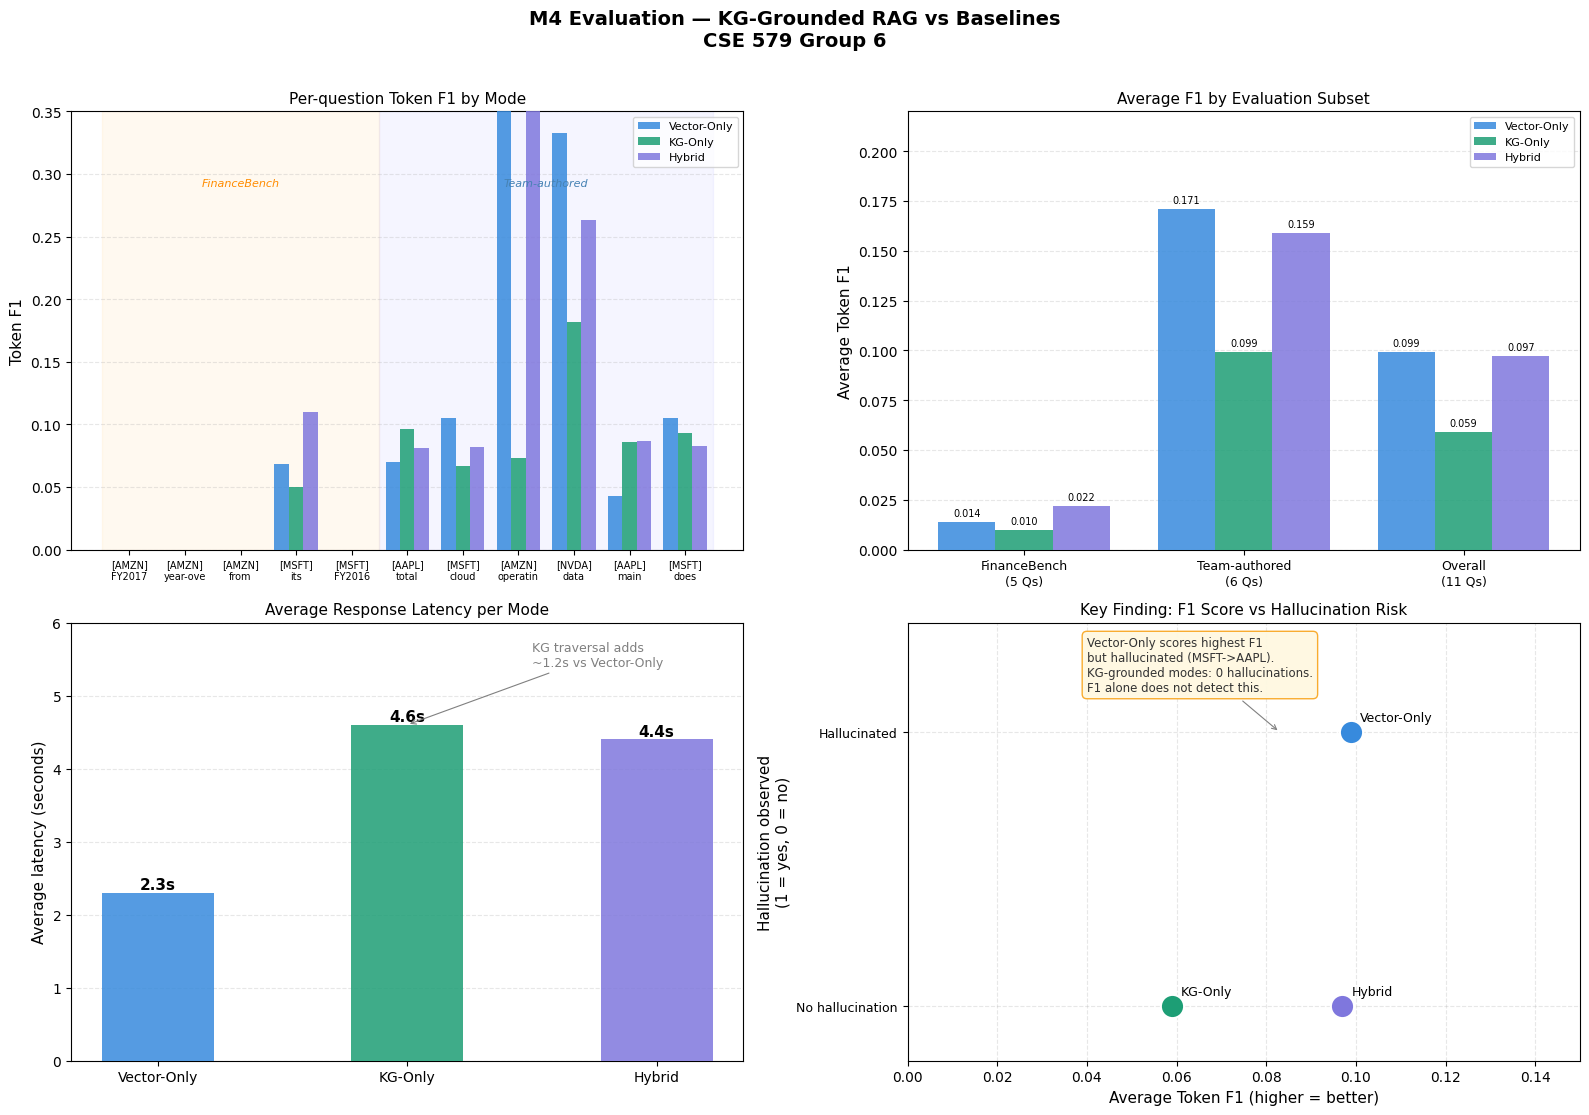

Saved: /content/m4_final_evaluation.png


In [84]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "M4 Evaluation — KG-Grounded RAG vs Baselines\n"
    "CSE 579 Group 6",
    fontsize=14, fontweight="bold", y=1.01
)

colors = {"vector_only": "#378ADD", "kg_only": "#1D9E75", "hybrid": "#7F77DD"}
modes  = ["vector_only", "kg_only", "hybrid"]
labels = ["Vector-Only", "KG-Only", "Hybrid"]

# ── Plot 1: Per-question F1 grouped bar ──────────────────────────────────────
ax1   = axes[0, 0]
x     = np.arange(len(m4_results))
w     = 0.26
qlabs = [f"[{r['ticker']}]\n{r['question'].split()[3][:8]}" for r in m4_results]

for i, (m, lbl) in enumerate(zip(modes, labels)):
    vals = [r[f"{m}_f1"] for r in m4_results]
    ax1.bar(x + (i-1)*w, vals, w, label=lbl,
            color=colors[m], alpha=0.85, zorder=3)

# shade FinanceBench region
ax1.axvspan(-0.5, 4.5, alpha=0.06, color="orange", zorder=0)
ax1.text(2, 0.29, "FinanceBench", ha="center", fontsize=8,
         color="darkorange", style="italic")
ax1.axvspan(4.5, 10.5, alpha=0.04, color="blue", zorder=0)
ax1.text(7.5, 0.29, "Team-authored", ha="center", fontsize=8,
         color="steelblue", style="italic")

ax1.set_ylabel("Token F1", fontsize=11)
ax1.set_title("Per-question Token F1 by Mode", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(qlabs, fontsize=7)
ax1.set_ylim(0, 0.35)
ax1.legend(fontsize=8)
ax1.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
ax1.set_axisbelow(True)

# ── Plot 2: Average F1 by subset ─────────────────────────────────────────────
ax2      = axes[0, 1]
subsets  = ["FinanceBench\n(5 Qs)", "Team-authored\n(6 Qs)", "Overall\n(11 Qs)"]
fb_avgs  = [avg_f1(fb_rows, m)   for m in modes]
ta_avgs  = [avg_f1(team_rows, m) for m in modes]
all_avgs = [avg_f1(all_rows, m)  for m in modes]

xs = np.arange(3)
for i, (m, lbl) in enumerate(zip(modes, labels)):
    vals = [fb_avgs[i], ta_avgs[i], all_avgs[i]]
    bars = ax2.bar(xs + (i-1)*0.26, vals, 0.26,
                   label=lbl, color=colors[m], alpha=0.85,
                   zorder=3)
    for bar, val in zip(bars, vals):
        if val > 0.005:
            ax2.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.003,
                     f"{val:.3f}", ha="center", fontsize=7)

ax2.set_ylabel("Average Token F1", fontsize=11)
ax2.set_title("Average F1 by Evaluation Subset", fontsize=11)
ax2.set_xticks(xs)
ax2.set_xticklabels(subsets, fontsize=9)
ax2.set_ylim(0, 0.22)
ax2.legend(fontsize=8)
ax2.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
ax2.set_axisbelow(True)

# ── Plot 3: Latency comparison ────────────────────────────────────────────────
ax3  = axes[1, 0]
lats = [avg_lat(all_rows, m) for m in modes]
bars = ax3.bar(labels, lats,
               color=[colors[m] for m in modes],
               alpha=0.85, width=0.45, zorder=3)
for bar, val in zip(bars, lats):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f"{val}s", ha="center", fontsize=11, fontweight="bold")

ax3.set_ylabel("Average latency (seconds)", fontsize=11)
ax3.set_title("Average Response Latency per Mode", fontsize=11)
ax3.set_ylim(0, 6)
ax3.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
ax3.set_axisbelow(True)
ax3.annotate("KG traversal adds\n~1.2s vs Vector-Only",
             xy=(1, lats[1]), xytext=(1.5, lats[1]+0.8),
             arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
             fontsize=9, color="gray")

# ── Plot 4: The key finding — F1 vs Hallucination ────────────────────────────
ax4 = axes[1, 1]
ax4.set_title("Key Finding: F1 Score vs Hallucination Risk", fontsize=11)

f1_scores = [avg_f1(all_rows, m) for m in modes]
hall_risk  = [1, 0, 0]   # Vector-Only hallucinated; KG-Only and Hybrid did not

scatter_colors = [colors[m] for m in modes]
for i, (m, lbl) in enumerate(zip(modes, labels)):
    ax4.scatter(f1_scores[i], hall_risk[i],
                s=280, color=colors[m], zorder=5,
                label=lbl, edgecolors="white", linewidths=1.5)
    ax4.annotate(
        lbl,
        xy=(f1_scores[i], hall_risk[i]),
        xytext=(f1_scores[i] + 0.002, hall_risk[i] + 0.04),
        fontsize=9
    )

ax4.set_xlabel("Average Token F1 (higher = better)", fontsize=11)
ax4.set_ylabel("Hallucination observed\n(1 = yes, 0 = no)", fontsize=11)
ax4.set_xlim(0, 0.15)
ax4.set_ylim(-0.2, 1.4)
ax4.set_yticks([0, 1])
ax4.set_yticklabels(["No hallucination", "Hallucinated"], fontsize=9)
ax4.grid(linestyle="--", alpha=0.3, zorder=0)
ax4.set_axisbelow(True)

# Annotation box
ax4.annotate(
    "Vector-Only scores highest F1\nbut hallucinated (MSFT->AAPL).\n"
    "KG-grounded modes: 0 hallucinations.\n"
    "F1 alone does not detect this.",
    xy=(0.083, 1), xytext=(0.04, 1.15),
    fontsize=8.5, color="#333",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff8e1",
              edgecolor="#f9a825", alpha=0.95),
    arrowprops=dict(arrowstyle="->", color="gray", lw=0.8)
)

plt.tight_layout()
plt.savefig("/content/m4_final_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/m4_final_evaluation.png")

# Saving the colab files

In [85]:
import os
import zipfile
from google.colab import files

# All important files to save
FILES_TO_SAVE = [
    # Data files
    "/content/faiss_index.bin",
    "/content/chunks_metadata.pkl",
    "/content/m2_eval_results.json",
    "/content/m3_consistency_results.json",
    "/content/m4_evaluation_results.json",
    # Charts
    "/content/m2_retrieval_comparison.png",
    "/content/m3_presentation_chart.png",
    "/content/m4_final_evaluation.png",
    # Python scripts
    "/content/module1_sec_ner_to_neo4j.py",
    "/content/download_10k_last20y.py",
]

ZIP_PATH = "/content/cse579_group6_session_backup.zip"

print("Creating zip archive...")
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    # Add individual files
    for fpath in FILES_TO_SAVE:
        if os.path.exists(fpath):
            arcname = os.path.basename(fpath)
            zf.write(fpath, arcname)
            print(f"  Added: {arcname}")
        else:
            print(f"  MISSING (skipped): {fpath}")

    # Add all SEC filings (sec_data folder)
    sec_data = "/content/sec_data"
    if os.path.exists(sec_data):
        for root, dirs, fnames in os.walk(sec_data):
            for fname in fnames:
                full = os.path.join(root, fname)
                arcname = os.path.relpath(full, "/content")
                zf.write(full, arcname)
        print(f"  Added: sec_data/ folder")

    # Add manifest csv
    manifest = "/content/sec_10k_last20y/manifest.csv"
    if os.path.exists(manifest):
        zf.write(manifest, "manifest.csv")
        print(f"  Added: manifest.csv")

size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
print(f"\nZip created: {ZIP_PATH}")
print(f"Size: {size_mb:.1f} MB")
print("\nStarting download...")
files.download(ZIP_PATH)

Creating zip archive...
  Added: faiss_index.bin
  Added: chunks_metadata.pkl
  Added: m2_eval_results.json
  Added: m3_consistency_results.json
  Added: m4_evaluation_results.json
  Added: m2_retrieval_comparison.png
  Added: m3_presentation_chart.png
  Added: m4_final_evaluation.png
  Added: module1_sec_ner_to_neo4j.py
  Added: download_10k_last20y.py
  Added: sec_data/ folder
  Added: manifest.csv

Zip created: /content/cse579_group6_session_backup.zip
Size: 15.1 MB

Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>